## Karate Club

Zachary's Karate Club graph

Data file from:
http://vlado.fmf.uni-lj.si/pub/networks/data/Ucinet/UciData.htm

Zachary W. (1977).
An information flow model for conflict and fission in small groups.
Journal of Anthropological Research, 33, 452-473.

In [38]:
import matplotlib.pyplot as plt
import networkx as nx
from collections import defaultdict
from matplotlib.colors import Normalize
def draw_communities(G, membership, pos):
    """Draws the nodes to a plot with assigned colors for each individual cluster
    Parameters
    ----------
    G : networkx graph
    membership : list
        A list where the position is the student and the value at the position is the student club membership.
        E.g. `print(membership[8]) --> 1` means that student #8 is a member of club 1.
    pos : positioning as a networkx spring layout
        E.g. nx.spring_layout(G)
    """ 
    fig, ax = plt.subplots(figsize=(8,6))
    
    # Convert membership list to a dict where key=club, value=list of students in club
    club_dict = defaultdict(list)
    for student, club in enumerate(membership):
        club_dict[club].append(student)
    
    # Normalize number of clubs for choosing a color
    norm = Normalize(vmin=0, vmax=len(club_dict.keys()))
    
    for club, members in club_dict.items():
        nx.draw_networkx_nodes(G, pos,
                               nodelist=members,
                               node_color=cm.jet(norm(club)),
                               node_size=200,
                               alpha=1,
                               ax=ax)
        nx.draw_networkx_labels(G, pos)
    # Draw edges (social connections) and show final plot
    plt.title("Zachary's Karate Club")
    nx.draw_networkx_edges(G, pos, alpha=0.5, ax=ax)
    ax.spines[['left', 'bottom', 'right', 'top']].set_visible(False)
G = nx.karate_club_graph()
pos = nx.spring_layout(G)

In [16]:
y_true = [0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 1, 1, 0, 0, 1, 0, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1]

D:\BackProgram\Anaconda\lib\site-packages\networkx\drawing\nx_pylab.py:450: UserWarning: *c* argument looks like a single numeric RGB or RGBA sequence, which should be avoided as value-mapping will have precedence in case its length matches with *x* & *y*.  Please use the *color* keyword-argument or provide a 2D array with a single row if you intend to specify the same RGB or RGBA value for all points.
  node_collection = ax.scatter(


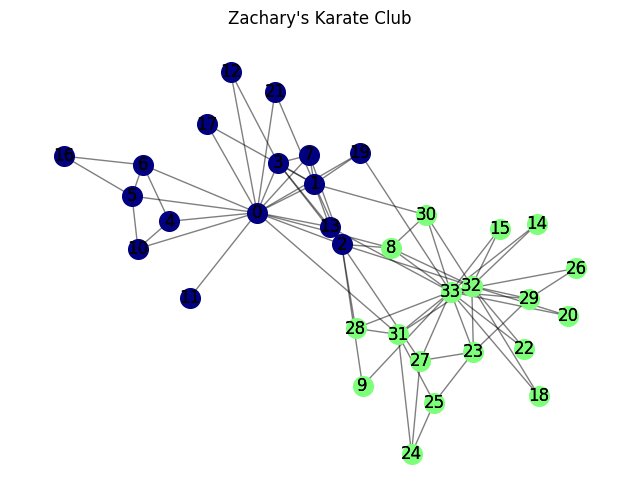

In [39]:
draw_communities(G, y_true, pos)
# save_path = "./_Figure/Thesis/" + "Zachary.pdf"
# plt.savefig(save_path, dpi=600)

# Nonbacktracking spectrum

In [1]:
from _HyperSBM import *
from _HyperCommunityDetection import *
from _SBMMatrix import *
from _FigureJiazeHelper import *
import matplotlib.pyplot as plt
from matplotlib.patches import Ellipse, Circle
from scipy.sparse.linalg import eigs, eigsh
from scipy.linalg import eig
from _CommunityDetect import *
from spectralOperator import BetheHessian
import warnings
warnings.filterwarnings('ignore', category=FutureWarning)

%load_ext autoreload
%autoreload 2

In [2]:
# Matplotlib settings

# plt.style.use('seaborn-whitegrid')
plt.rc('figure', figsize=(8, 5))
plt.rc('font', size=16)
plt.rc('font', family='sans-serif')
plt.rcParams['font.sans-serif'] = 'verdana'
plt.rcParams['lines.linewidth'] = 4
plt.rcParams['axes.spines.right'] = False
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.edgecolor'] = basic_line_color
plt.rcParams['xtick.color'] = basic_line_color
plt.rcParams['ytick.color'] = basic_line_color
plt.rcParams['axes.labelsize'] = 'large'
plt.rcParams['lines.markersize'] = 12

%config InlineBackend.figure_format = 'retina'

In [3]:
def scatter_spectral(eigvalue, fig=None, ax=None, title='Spectrum', title_x=0.25):
    # Construct scatter coordinate
    x = []
    y = []
    for _w in eigvalue:
        _x = _w.real if isinstance(_w, complex) else _w
        _y = _w.imag if isinstance(_w, complex) else 0
        x.append(_x)
        y.append(_y)
    if fig is None and ax is None:
        fig = plt.figure(figsize=(8, 8))
        widths = [4]
        heights = [4]
        spec5 = fig.add_gridspec(ncols=1, nrows=1, width_ratios=widths, height_ratios=heights)
        row = 0
        col = 0
        ax = fig.add_subplot(spec5[row, col])
    ax.set_aspect('equal',adjustable='box')
    ax.spines['top'].set_color('none')
    ax.spines['right'].set_color('none')
#     ax.xaxis.set_ticks_position('bottom')
    ax.spines['bottom'].set_position(('data', 0))
#     ax.yaxis.set_ticks_position('left')
    ax.spines['left'].set_position(('data', 0))
    ax.scatter(x, y, s=6)
    ax.set_title(title, x=title_x, y=1.07)

In [38]:
def plot_spectral_NBBH(sbm, bulk, extend_vline=2.65, eig_B=None, ylabel_coor1=(0.25,0.95), ylabel_coor2=(0.2,0.95), 
                       title_x=0.25, eigBH_amplify=1, xlabel_x=1.02):
#     print(f'SNR={sbm.get_SNR()}, d={d}')
    if eig_B is None:
        NB = sbm.get_operator('NB')
        print(np.shape(NB))
        eig_B, _ = eig(NB.toarray())
    info_eig = []
#     bulk = np.sqrt(d)
    for e in eig_B:
        if abs(e) > bulk and e.imag == 0:
            info_eig.append(e)
    print(info_eig)
    fig = plt.figure(figsize=(8, 8))
    widths = [5]
    heights = [5]
    spec5 = fig.add_gridspec(ncols=1, nrows=1, width_ratios=widths, height_ratios=heights)
    row = 0
    col = 0
    ax = fig.add_subplot(spec5[row, col])
    scatter_spectral(eig_B, fig=fig, ax=ax, title=r"", title_x=title_x)
    ax.add_patch(Circle(xy = (0.0, 0.0), radius=bulk, alpha=0.2))
    # ax.set_ylim(-bulk-1, 1 * bulk + 1)
    # ax.set_xlim(-bulk-1, max(info_eig).real+1)
    # left, right = ax.get_xlim()
    # for e in info_eig:
        # ax.axvline(e.real, c='black', ls=':', lw=1)
    # ax.axvline(bulk, c='black', ls='-', lw=1)
    ax.set_xlabel('real', loc='right', size=15)
    ax.set_ylabel('imag', loc='top', size=15, rotation=0)
    # ax.yaxis.set_label_coords(ylabel_coor1[0],ylabel_coor1[1])
    # ax.xaxis.set_label_coords(xlabel_x, 0.4)
    ax.apply_aspect()

pin=0.07142857142857142, pout=0.014285714285714285


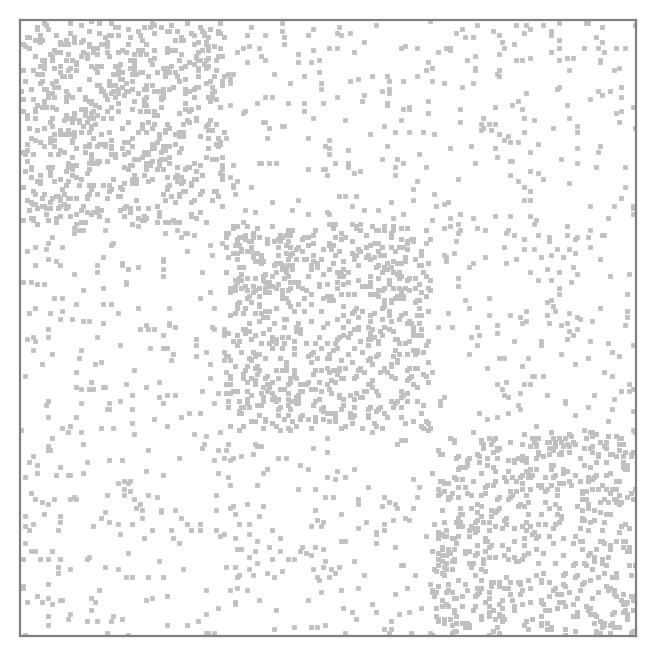

In [30]:
# Symmetric
n = 300
k = 3
d = 10
epsilon = 0.2
net = SymmetricSBM.init_epsc(n, k, d, epsilon)

fig = plt.figure(figsize=(4, 4))
widths = [4]
heights = [4]
spec5 = fig.add_gridspec(ncols=1, nrows=1, width_ratios=widths, height_ratios=heights)
row = 0
col = 0
ax = fig.add_subplot(spec5[row, col])
c = [gray, gray, gray]
plot_block_matrix(net.A.toarray(), partition_names=list(range(len(net.sizes))), partition_counts=net.sizes, colors=c, label="", ms=1, show_legend=False)
ax.spines.right.set_visible(True)
ax.spines.top.set_visible(True)
save_path = "./_Figure/Thesis/" + "AdjacentMatrix_SBM.pdf"
# plt.tight_layout()
plt.savefig(save_path, dpi=600)

(2970, 2970)
[(9.81371302766146+0j), (5.813399228015302+0j), (4.715975305541081+0j)]


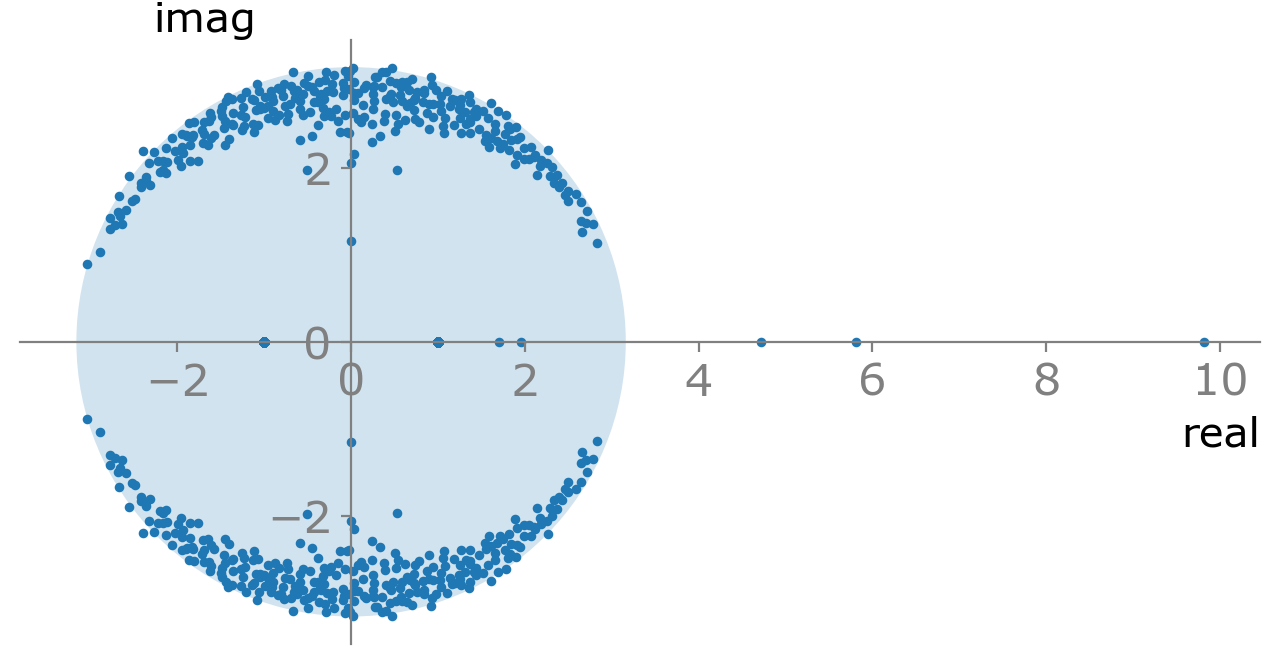

In [40]:
plot_spectral_NBBH(net, bulk=np.sqrt(d))
save_path = "./_Figure/Thesis/" + "Spectrum_NB.pdf"
# plt.tight_layout()
plt.savefig(save_path, dpi=600)

# Detectability illustration

In [1]:
from _SBMMatrix import *
from _FigureJiazeHelper import *
import matplotlib.pyplot as plt
from matplotlib.patches import Ellipse, Circle
from scipy.sparse.linalg import eigs, eigsh
from scipy.linalg import eig
from _CommunityDetect import *
from spectralOperator import BetheHessian
import warnings
warnings.filterwarnings('ignore', category=FutureWarning)

%load_ext autoreload
%autoreload 2

In [2]:
# Matplotlib settings

# plt.style.use('seaborn-whitegrid')
plt.rc('figure', figsize=(8, 5))
plt.rc('font', size=16)
plt.rc('font', family='sans-serif')
plt.rcParams['font.sans-serif'] = 'verdana'
plt.rcParams['lines.linewidth'] = 4
plt.rcParams['axes.spines.right'] = False
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.edgecolor'] = basic_line_color
plt.rcParams['xtick.color'] = basic_line_color
plt.rcParams['ytick.color'] = basic_line_color
plt.rcParams['axes.labelsize'] = 'large'
plt.rcParams['lines.markersize'] = 12

%config InlineBackend.figure_format = 'retina'

snr=13.230000000000002


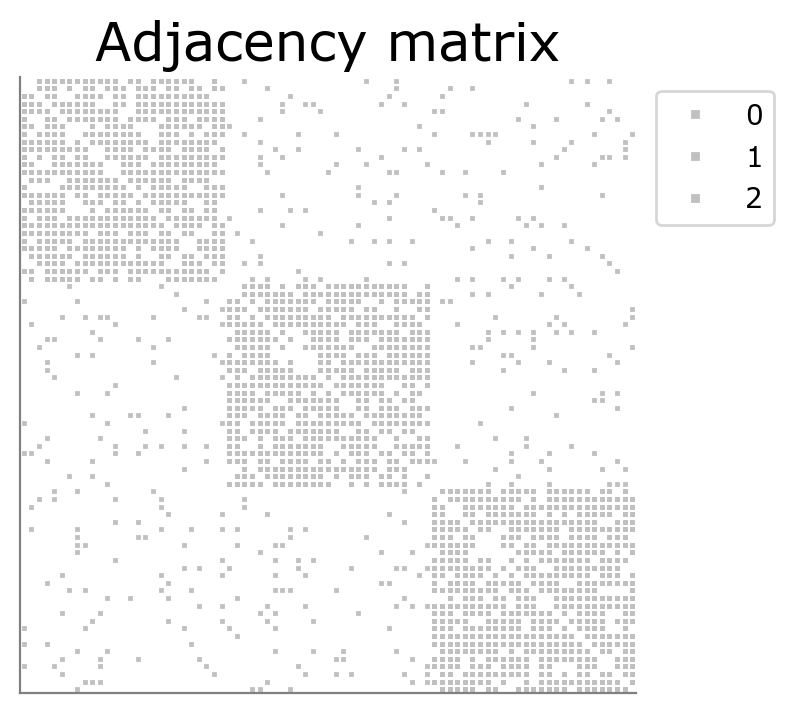

In [41]:
# Symmetric
n = 3**4
k = 3
# d = 10
# epsilon = 1
# net = SymmetricSBM.init_epsc(n, k, d, epsilon)
# net = SymmetricSBM(n, k, pin=1, pout=0.2)
# net = SymmetricSBM(n, k, pin=1, pout=0)
pin = 0.8
pout = 0.1
net = SymmetricSBM(n, k, pin=pin, pout=pout)
# epsilon = 0.1
# SymmetricSBM.init_epsc(n, k, c=d, epsilon=epsilon)
snr = n * (pin - pout)**2 / (k * (pin + (k-1)* pout))
print(f'snr={snr}')
fig = plt.figure(figsize=(4, 4))
widths = [4]
heights = [4]
spec5 = fig.add_gridspec(ncols=1, nrows=1, width_ratios=widths, height_ratios=heights)
row = 0
col = 0
ax = fig.add_subplot(spec5[row, col])
c = gen_colors(start=gray, end=gray, n=len(net.sizes))
plot_block_matrix(net.A.toarray(), partition_names=list(range(len(net.sizes))), partition_counts=net.sizes, colors=c)
# print(net.A.toarray())
pos = nx.spring_layout(net.g)

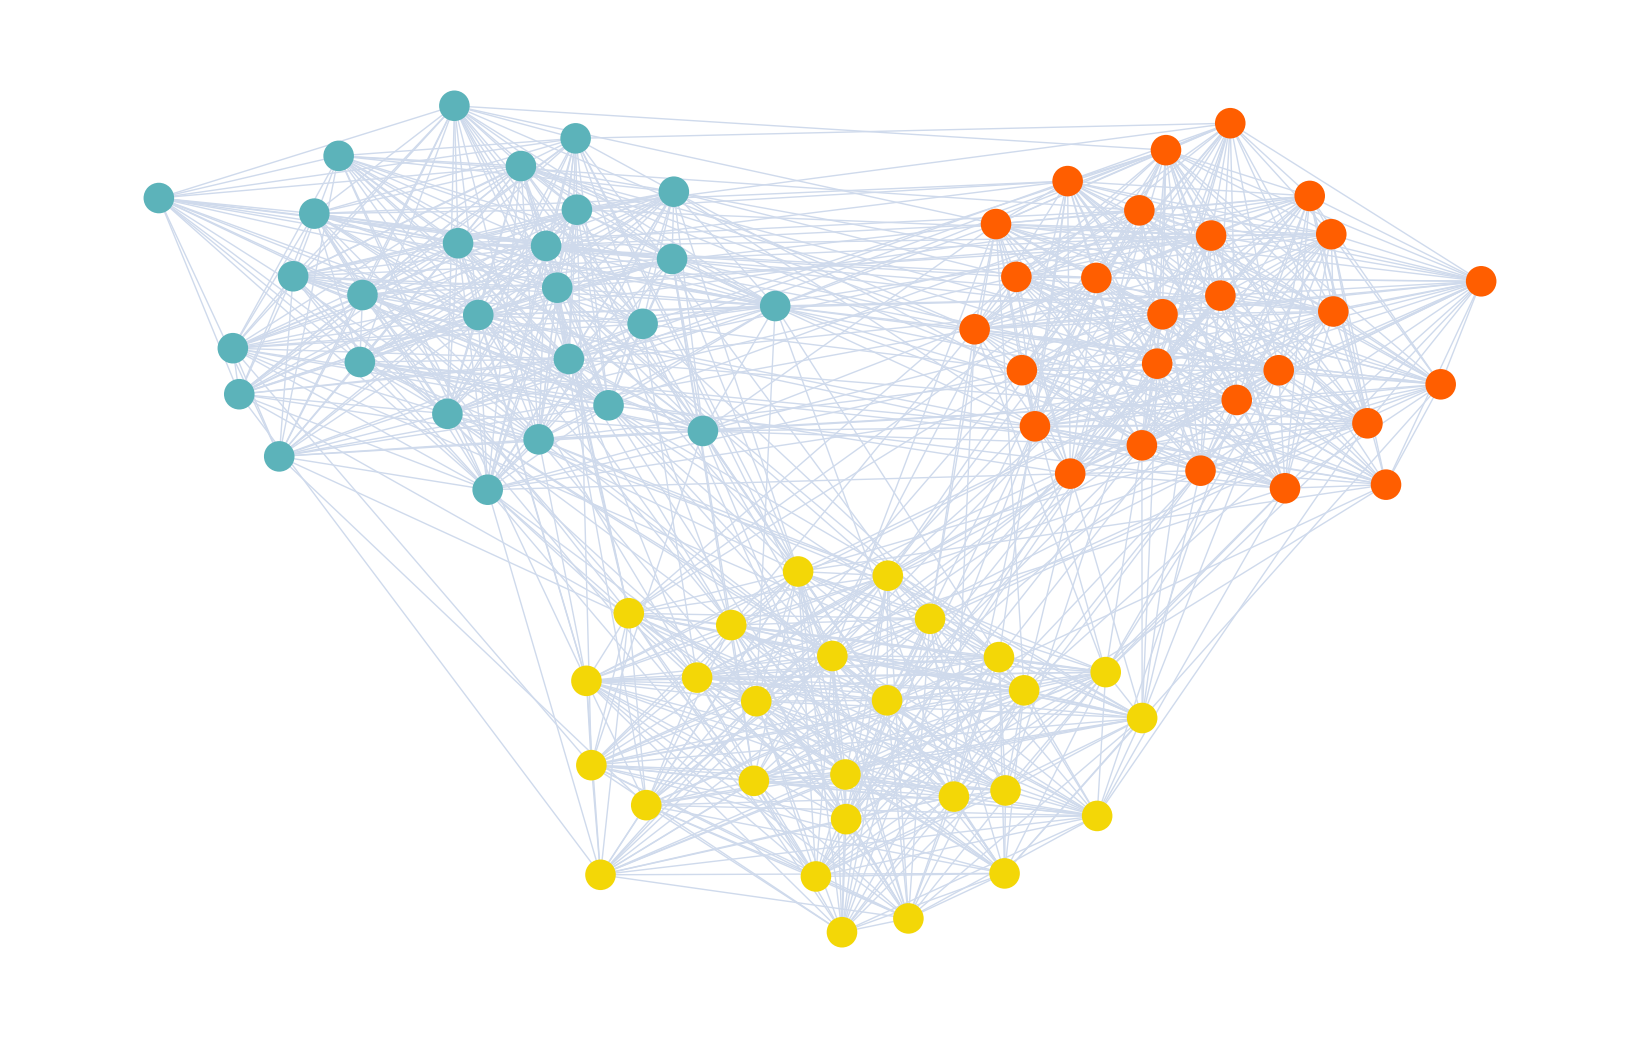

In [42]:
node_color='#91CAE8' # '#1f78b4'  # blue
node_color='gray'
node_color = ['#5CB3BA'] * int(n/k)+['#F3D707']*int(n/k)+['#FF5E00']*int(n/k)
edge_color='#CFDAEC'

nx.draw(net.g, pos=pos, node_size=100, node_color=node_color, edge_color=edge_color, width=0.5)
save_path = "./_Figure/Thesis/" + f"SBM_pin{pin}_pout{pout}.pdf"
# plt.tight_layout()
plt.savefig(save_path, dpi=600)

snr=27.0


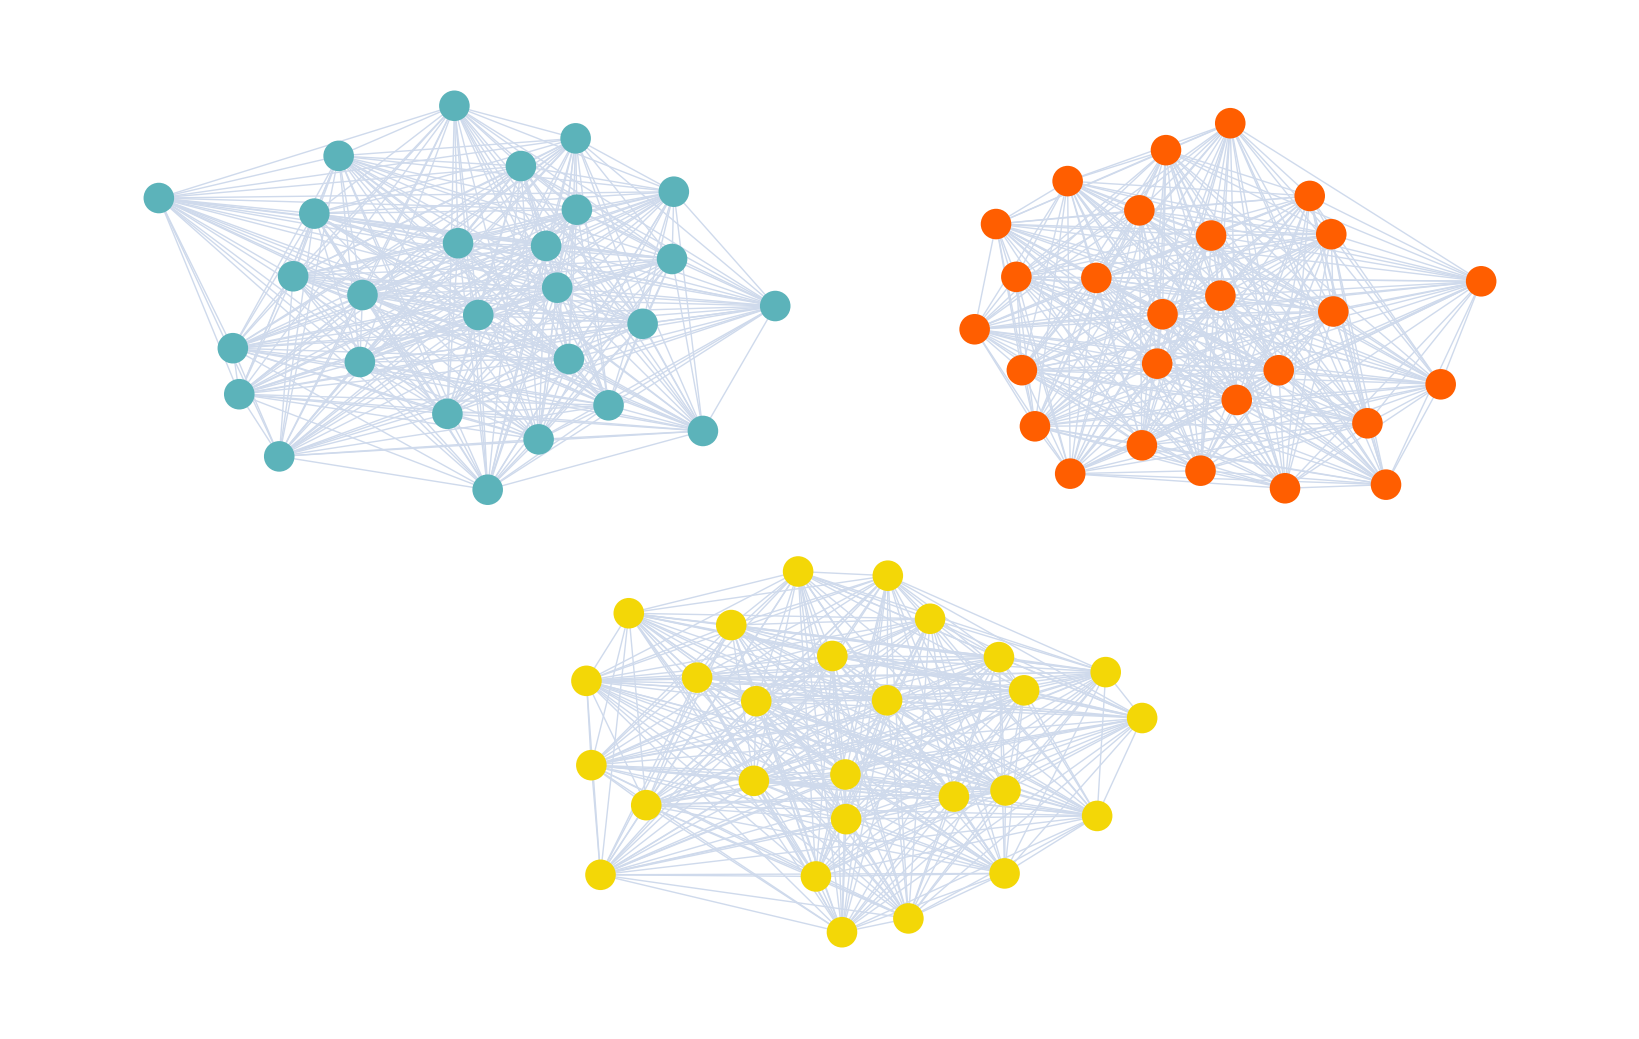

In [43]:
pin = 1
pout = 0
net = SymmetricSBM(n, k, pin=pin, pout=pout)
snr = n * (pin - pout)**2 / (k * (pin + (k-1)* pout))
print(f'snr={snr}')
node_color = ['#5CB3BA'] * int(n/k)+['#F3D707']*int(n/k)+['#FF5E00']*int(n/k)
edge_color='#CFDAEC'
nx.draw(net.g, pos=pos, node_size=100, node_color=node_color, edge_color=edge_color, width=0.5)
save_path = "./_Figure/Thesis/" + f"SBM_pin{pin}_pout{pout}.pdf"
# plt.tight_layout()
plt.savefig(save_path, dpi=600)

snr=0.2700000000000002


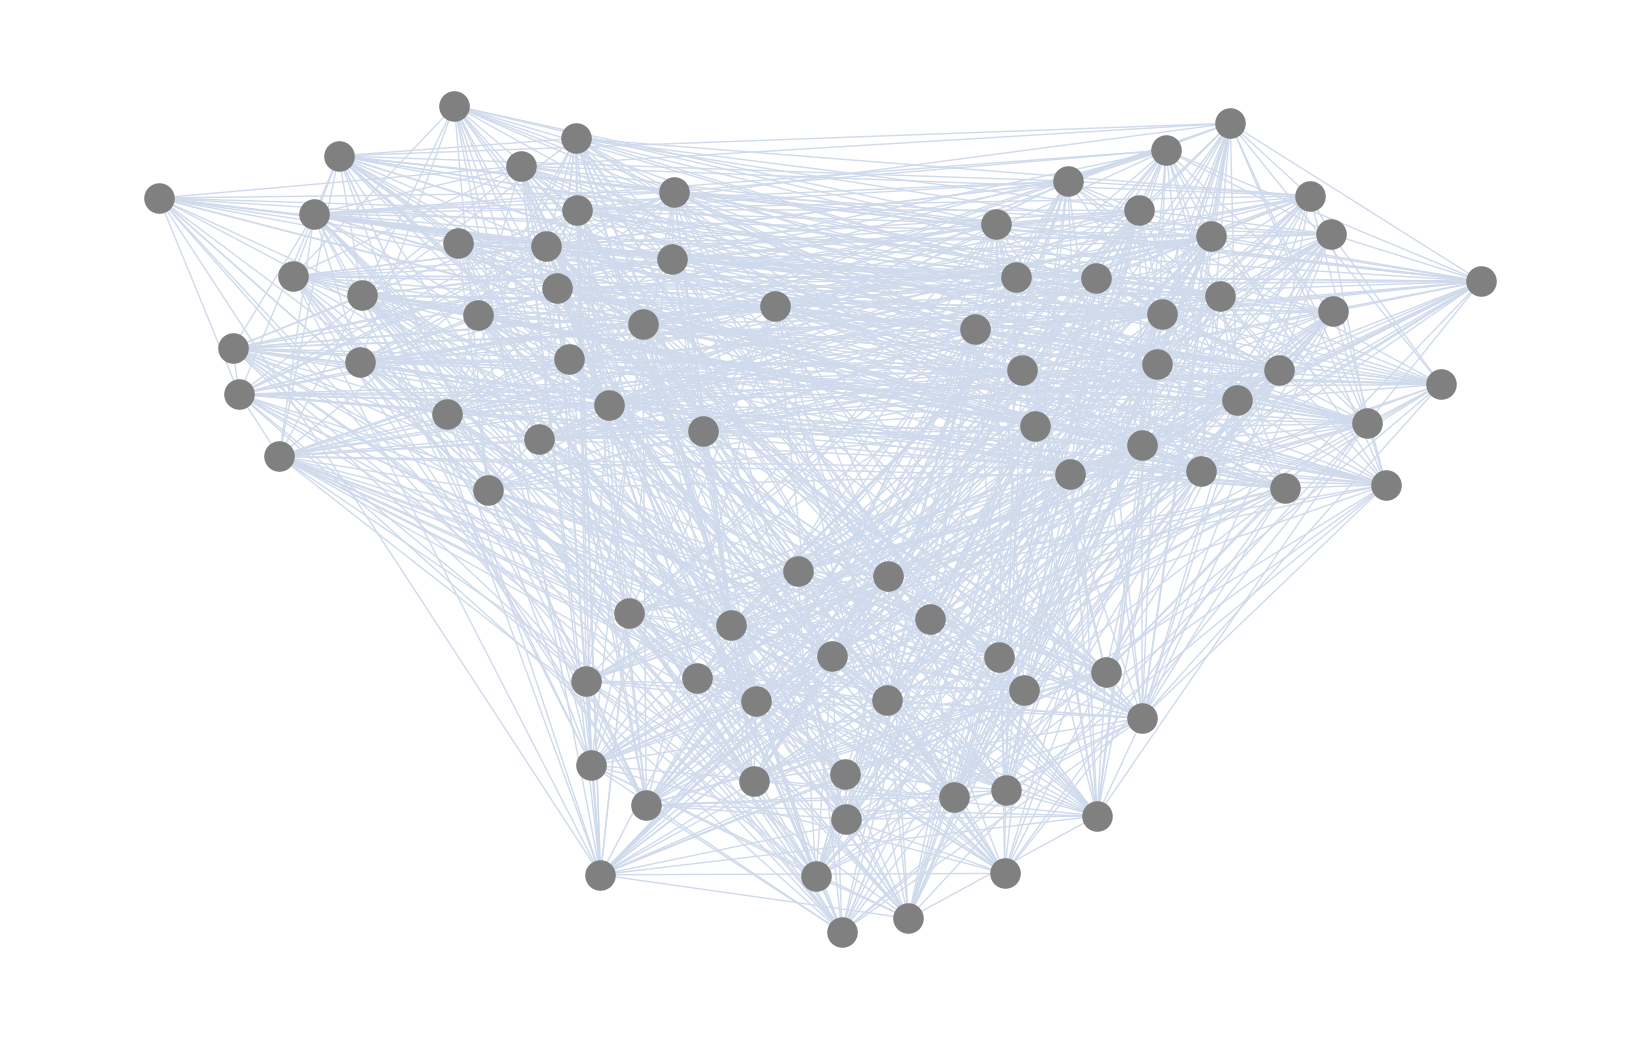

In [45]:
pin = 0.4
pout = 0.3
net = SymmetricSBM(n, k, pin=pin, pout=pout)
snr = n * (pin - pout)**2 / (k * (pin + (k-1)* pout))
print(f'snr={snr}')
node_color = 'gray'
edge_color='#CFDAEC'
nx.draw(net.g, pos=pos, node_size=100, node_color=node_color, edge_color=edge_color, width=0.5)
save_path = "./_Figure/Thesis/" + f"SBM_pin{pin}_pout{pout}.pdf"
# plt.tight_layout()
plt.savefig(save_path, dpi=600)

snr=0.0


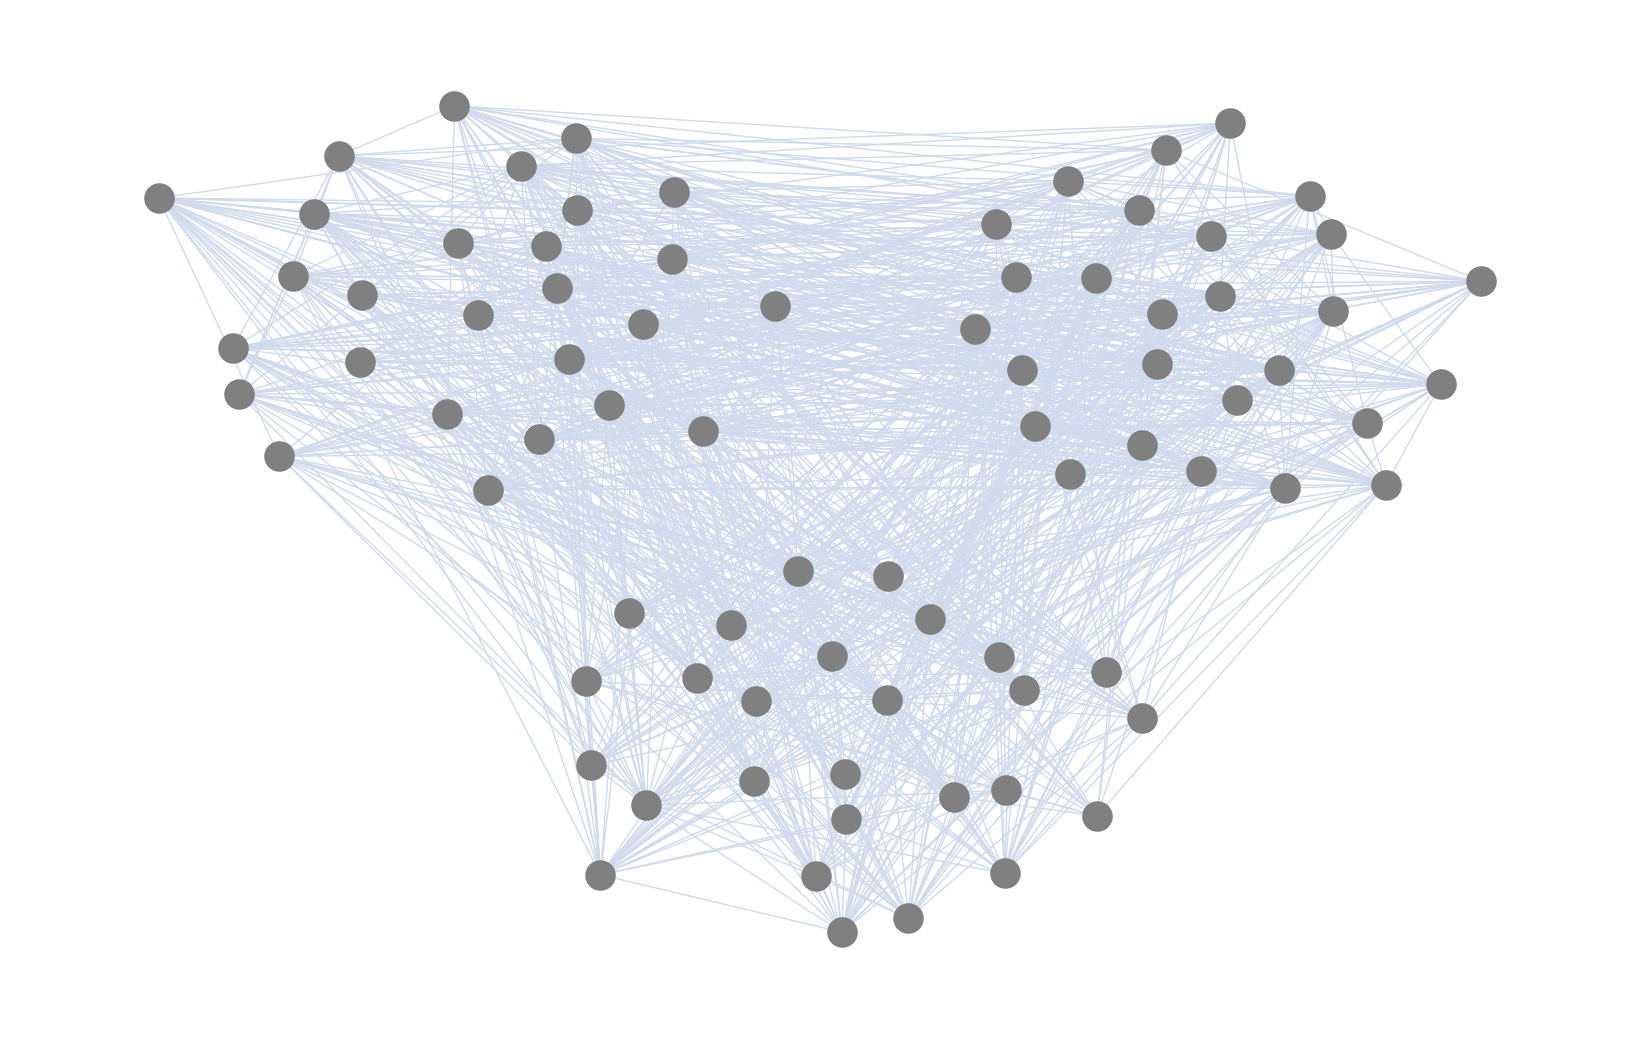

In [46]:
pin = 1/3
pout = 1/3
net = SymmetricSBM(n, k, pin=pin, pout=pout)
snr = n * (pin - pout)**2 / (k * (pin + (k-1)* pout))
print(f'snr={snr}')
node_color='gray'
edge_color='#CFDAEC'
nx.draw(net.g, pos=pos, node_size=100, node_color=node_color, edge_color=edge_color, width=0.5)
save_path = "./_Figure/Thesis/" + f"SBM_pin{pin}_pout{pout}.pdf"
# plt.tight_layout()
plt.savefig(save_path, dpi=600)

# Minority Detectability Illustration

# Regime of symmetric SBM

In [31]:
import matplotlib.pyplot as plt
import matplotlib as mpl
import contourpy
from matplotlib.colors import LinearSegmentedColormap, ListedColormap
import matplotlib.colors as colors
from matplotlib.ticker import FormatStrFormatter
import numpy as np
from _FigureJiazeHelper import *
from _DetectabilityWithMeta import *
from _CommunityDetect import *
from EXPERIMENT_MINORITY import *
from scipy.optimize import linear_sum_assignment

%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [2]:
# Matplotlib settings

# plt.style.use('seaborn-whitegrid')
plt.rc('figure', figsize=(8, 5))
plt.rc('font', size=10)
plt.rc('font', family='sans-serif')
plt.rcParams['font.sans-serif'] = 'verdana'
plt.rcParams['lines.linewidth'] = 4
plt.rcParams['axes.spines.right'] = False
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.edgecolor'] = basic_line_color
plt.rcParams['xtick.color'] = basic_line_color
plt.rcParams['ytick.color'] = basic_line_color
plt.rcParams['axes.labelsize'] = 10  # 'large'
plt.rcParams['lines.markersize'] = 12
plt.rcParams['axes.linewidth'] = 0.5

# %matplotlib notebook
%config InlineBackend.figure_format = 'retina'

In [27]:
n = 1000
q = 4
din = n/q * np.linspace(0.01, 0.1, 200)
dout = n/q * np.linspace(0.01, 0.1, 200)
d = np.zeros(np.size(dout)*np.size(din))
snr = np.zeros(np.size(dout)*np.size(din))
ch = np.zeros(np.size(dout)*np.size(din))
it = np.zeros(np.size(dout)*np.size(din))
color = np.zeros(np.size(dout)*np.size(din))
i = 0
for di in din:
    for do in dout:
        d[i] = di + (q-1) * do
        snr[i] = (di - do) ** 2 / d[i]
        ch[i] = (np.sqrt(di)-np.sqrt(do))**2 / np.log(n)
        a = di * q / n
        b = do * q / n
        # use Theorem 1 in https://proceedings.neurips.cc/paper_files/paper/2018/file/1dba3025b159cd9354da65e2d0436a31-Paper.pdf
        it[i] = ((a-b)**2/(b* (1-b))) / (2*np.log(2)/n-4*np.log(2)/(n)**2)
        if it[i] < 1:
            color[i] = 0
        elif snr[i] < 1:
            color[i] = 1
        elif ch[i] < 1:
            color[i] = 2
        else:
            color[i] = 3
        i += 1

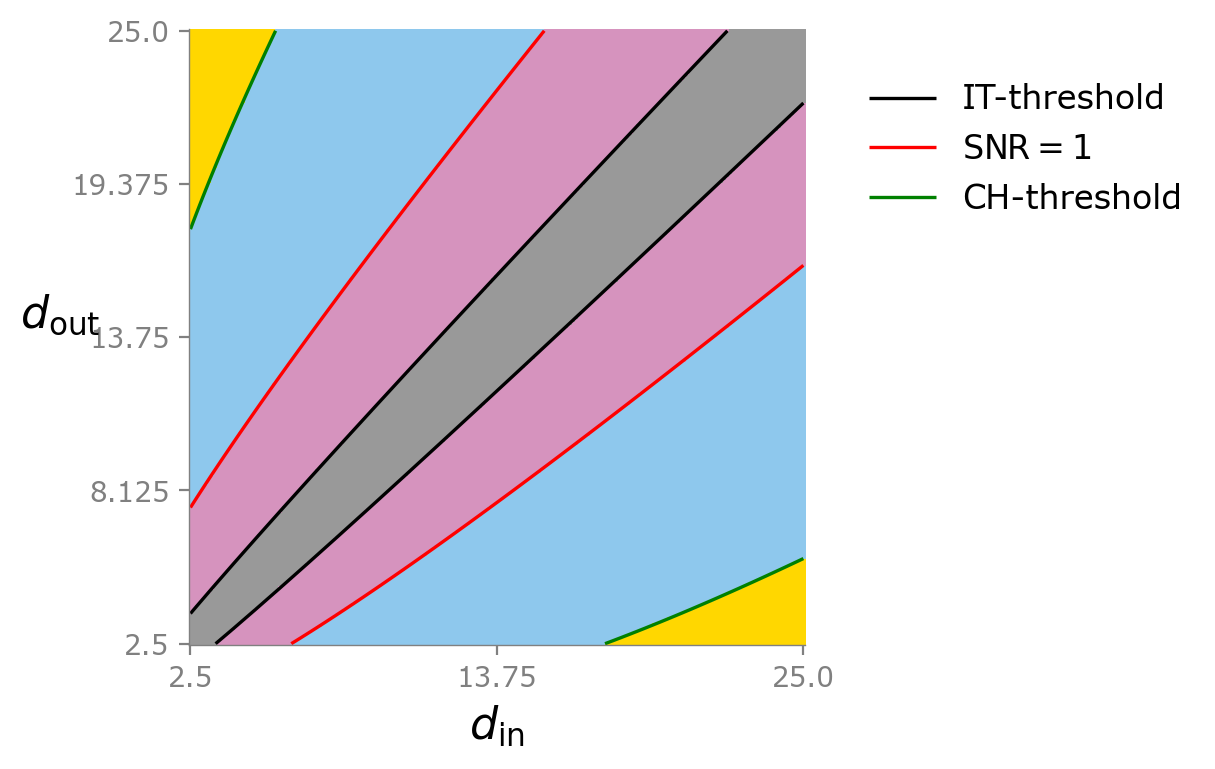

In [35]:
# figsize (width, height) with inch, 1 inch = 72 pt
fig = plt.figure(figsize=(4, 4))
widths = [3]
heights = [3]
spec5 = fig.add_gridspec(ncols=1, nrows=1, width_ratios=widths, height_ratios=heights)
row = 0
col = 0
ax = fig.add_subplot(spec5[row, col])
# cmap = mpl.colormaps["plasma"]
cmap = ListedColormap(["#999999", "#D693BE", "#8EC8ED", "gold"])
plot_din = np.repeat(din, np.size(dout))
plot_dout = np.tile(dout, np.size(din))
zcenter = 1
color_imshow_2d(plot_din, plot_dout, color, z_center=1.5, title="", xlabel=r'$d_{\rm in}$', 
                              ylabel=r'$d_{\rm out}$', cmap=cmap, ax=ax, fig=fig, set_yticks=True, show_colorbar=False)
plot_snr = color_imshow_2d(plot_din, plot_dout, snr, z_center=zcenter, return_gridz=True)
plot_ch = color_imshow_2d(plot_din, plot_dout, ch, z_center=zcenter, return_gridz=True)
plot_it = color_imshow_2d(plot_din, plot_dout, it, z_center=zcenter, return_gridz=True)
# ax.set_xlabel(r'$\rho$', fontsize=20)
handels = []
handels += contour_data(plot_it, ax, levels=[1], fmt={1: r'IT-threshold'}, color='black', inline=False)
handels += contour_data(plot_snr, ax, levels=[1], fmt={1e-3: r'$\rm SNR=1$'}, color='red', inline=False)
handels += contour_data(plot_ch, ax, levels=[1], fmt={1: r'CH-threshold'}, color='green', inline=False)


lgd = fig.legend(handels, [r'IT-threshold', r'$\rm SNR=1$', r'CH-threshold'], 
           loc=2, bbox_to_anchor=(0.94, 0.85),  fontsize=12, markerscale=2, frameon=False)
plt.subplots_adjust(wspace=0.8)
save_path = "./_Figure/Thesis/" + "Figure_SBMRegime.pdf"
# plt.tight_layout()
plt.savefig(save_path, dpi=600, bbox_extra_artists=(lgd,), bbox_inches='tight')

# Visualization Matrix/Tensor representation

In [1]:
from EXPERIMENT_HYPER_EMPIRICAL import *
from _FigureJiazeHelper import *
import matplotlib.pyplot as plt
from matplotlib.patches import Ellipse, Circle
import matplotlib.colors as colors
from scipy.sparse.linalg import eigs, eigsh
from scipy.linalg import eig
from scipy.sparse import diags, csc_matrix
import hypergraphx as hgx
from _HyperCommunityDetection import *
from hypergraphx.viz import draw_communities
from hypergraphx.viz.draw_hypergraph import draw_hypergraph
import warnings
import pandas
import random
warnings.filterwarnings('ignore', category=FutureWarning)

%load_ext autoreload
%autoreload 2

In [2]:
# Matplotlib settings

# plt.style.use('seaborn-whitegrid')
plt.rc('figure', figsize=(8, 5))
plt.rc('font', size=16)
plt.rc('font', family='sans-serif')
plt.rcParams['font.sans-serif'] = 'verdana'
plt.rcParams['lines.linewidth'] = 4
plt.rcParams['axes.spines.right'] = False
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.edgecolor'] = basic_line_color
plt.rcParams['xtick.color'] = basic_line_color
plt.rcParams['ytick.color'] = basic_line_color
plt.rcParams['axes.labelsize'] = 'large'
plt.rcParams['lines.markersize'] = 12

%config InlineBackend.figure_format = 'retina'

In [3]:
B = np.array([[1, 1, 0, 0, 0], [1, 1, 1, 1, 0], [0, 1, 1, 1, 1], [0, 0, 1, 0, 1]])
print(B)

[[1 1 0 0 0]
 [1 1 1 1 0]
 [0 1 1 1 1]
 [0 0 1 0 1]]


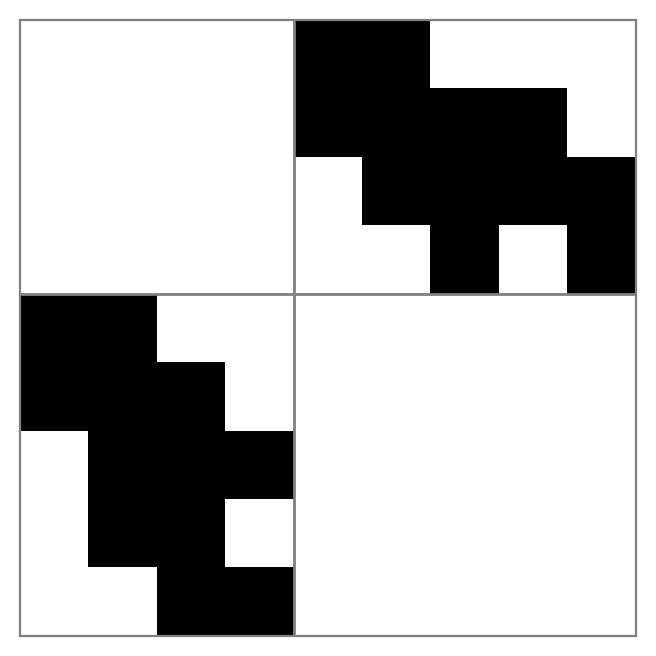

In [11]:
fig = plt.figure(figsize=(4, 4))
widths = [4]
heights = [4]
spec5 = fig.add_gridspec(ncols=1, nrows=1, width_ratios=widths, height_ratios=heights)
row = 0
col = 0
ax = fig.add_subplot(spec5[row, col])
lefttop = np.zeros((4, 4))
rightbottom = np.zeros((5, 5))
bipartite_A = np.vstack([np.hstack([lefttop, B]), np.hstack([B.T, rightbottom])])
ax.matshow(bipartite_A, cmap="binary")
ax.set_xticks([])
ax.set_yticks([])
ax.spines['right'].set_visible(True)
ax.spines['top'].set_visible(True)
plt.axvline(3.5, color='grey', lw=1)
plt.axhline(3.5, color='grey', lw=1)
save_path = "./_Figure/Thesis/" + "Figure_IllustrationBipartite.pdf"
# plt.tight_layout()
plt.savefig(save_path, dpi=600, bbox_extra_artists=None, bbox_inches='tight')

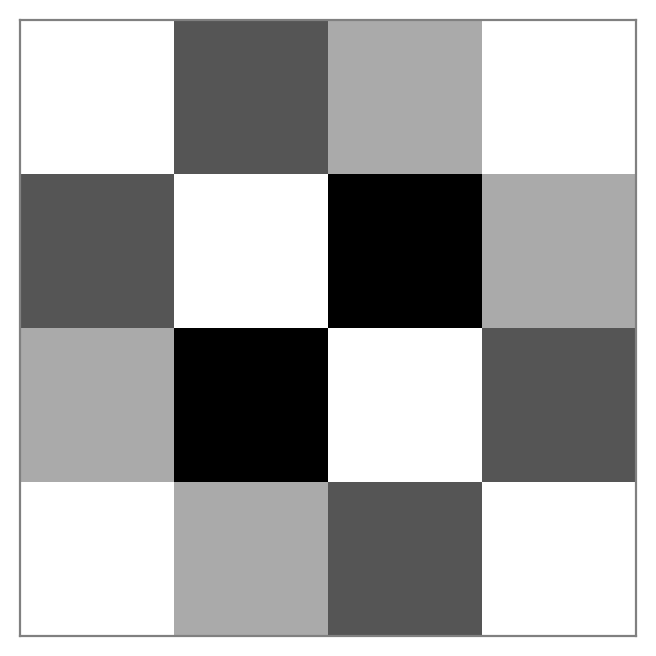

In [13]:
fig = plt.figure(figsize=(4, 4))
widths = [4]
heights = [4]
spec5 = fig.add_gridspec(ncols=1, nrows=1, width_ratios=widths, height_ratios=heights)
row = 0
col = 0
ax = fig.add_subplot(spec5[row, col])
ax.matshow(np.dot(B, B.T)-np.diag(np.diag(np.dot(B, B.T))), cmap="binary")
ax.set_xticks([])
ax.set_yticks([])
ax.spines['right'].set_visible(True)
ax.spines['top'].set_visible(True)
plt.axvline(3.5, color='grey', lw=1)
plt.axhline(3.5, color='grey', lw=1)
save_path = "./_Figure/Thesis/" + "Figure_IllustrationOneMode.pdf"
# plt.tight_layout()
plt.savefig(save_path, dpi=600, bbox_extra_artists=None, bbox_inches='tight')

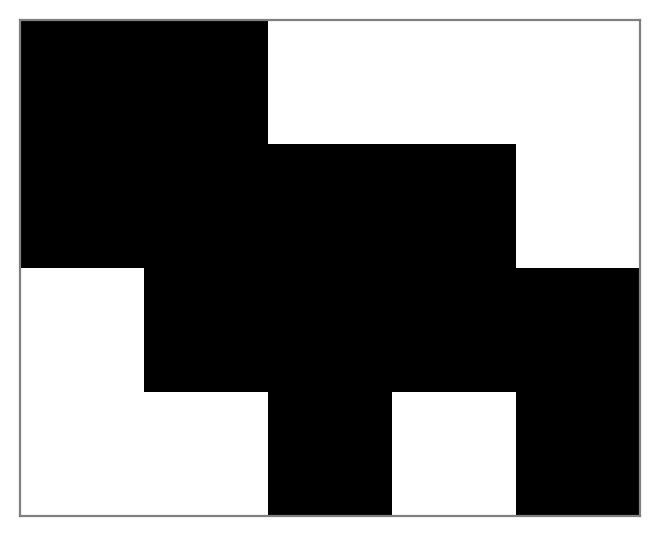

In [15]:
fig = plt.figure(figsize=(4, 4))
widths = [4]
heights = [4]
spec5 = fig.add_gridspec(ncols=1, nrows=1, width_ratios=widths, height_ratios=heights)
row = 0
col = 0
ax = fig.add_subplot(spec5[row, col])
ax.matshow(B, cmap="binary")
ax.set_xticks([])
ax.set_yticks([])
ax.spines['right'].set_visible(True)
ax.spines['top'].set_visible(True)
save_path = "./_Figure/Thesis/" + "Figure_IllustrationIncidenceHyper.pdf"
# plt.tight_layout()
plt.savefig(save_path, dpi=600, bbox_extra_artists=None, bbox_inches='tight')

# Spectrum of NHBH for SBM

In [1]:
from _HyperSBM import *
from _HyperCommunityDetection import *
from _SBMMatrix import *
from _FigureJiazeHelper import *
import matplotlib.pyplot as plt
from matplotlib.patches import Ellipse, Circle
from scipy.sparse.linalg import eigs, eigsh
from scipy.linalg import eig
from _CommunityDetect import *
from spectralOperator import BetheHessian
import warnings
warnings.filterwarnings('ignore', category=FutureWarning)

%load_ext autoreload
%autoreload 2

In [2]:
# Matplotlib settings

# plt.style.use('seaborn-whitegrid')
plt.rc('figure', figsize=(8, 5))
plt.rc('font', size=16)
plt.rc('font', family='sans-serif')
plt.rcParams['font.sans-serif'] = 'verdana'
plt.rcParams['lines.linewidth'] = 4
plt.rcParams['axes.spines.right'] = False
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.edgecolor'] = basic_line_color
plt.rcParams['xtick.color'] = basic_line_color
plt.rcParams['ytick.color'] = basic_line_color
plt.rcParams['axes.labelsize'] = 'large'
plt.rcParams['lines.markersize'] = 12

%config InlineBackend.figure_format = 'retina'

pin=0.09090909090909091, pout=0.004545454545454546


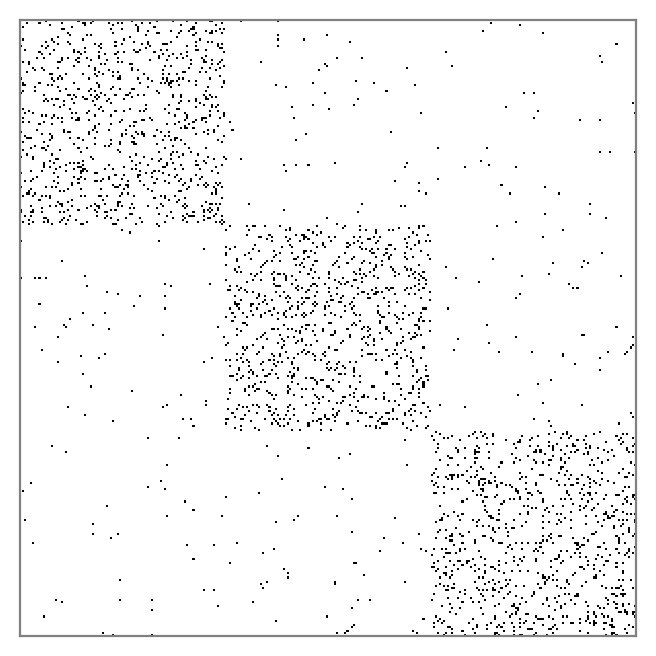

In [14]:
# Symmetric
n = 300
k = 3
d = 10
epsilon = 0.05
net = SymmetricSBM.init_epsc(n, k, d, epsilon)

fig = plt.figure(figsize=(4, 4))
widths = [4]
heights = [4]
spec5 = fig.add_gridspec(ncols=1, nrows=1, width_ratios=widths, height_ratios=heights)
row = 0
col = 0
ax = fig.add_subplot(spec5[row, col])
ax.matshow(net.A.toarray(), cmap="binary")
ax.set_xticks([])
ax.set_yticks([])
ax.spines['right'].set_visible(True)
ax.spines['top'].set_visible(True)

In [5]:
def scatter_spectral(eigvalue, fig=None, ax=None, title='Spectrum', title_x=0.25):
    # Construct scatter coordinate
    x = []
    y = []
    for _w in eigvalue:
        _x = _w.real if isinstance(_w, complex) else _w
        _y = _w.imag if isinstance(_w, complex) else 0
        x.append(_x)
        y.append(_y)
    if fig is None and ax is None:
        fig = plt.figure(figsize=(8, 8))
        widths = [4]
        heights = [4]
        spec5 = fig.add_gridspec(ncols=1, nrows=1, width_ratios=widths, height_ratios=heights)
        row = 0
        col = 0
        ax = fig.add_subplot(spec5[row, col])
    # ax.set_aspect('equal',adjustable='box')
    ax.spines['top'].set_color('none')
    ax.spines['right'].set_color('none')
#     ax.xaxis.set_ticks_position('bottom')
    ax.spines['bottom'].set_position(('data', 0))
#     ax.yaxis.set_ticks_position('left')
    ax.spines['left'].set_position(('data', 0))
    ax.scatter(x, y, s=6)
    ax.set_title(title, x=title_x, y=1.07, size=18)

In [17]:
def plot_spectral_NBBH(sbm, bulk, extend_vline=2.65, eig_B=None, ylabel_coor1=(0.25,0.95), ylabel_coor2=(0.2,0.95), 
                       title_x=0.25, eigBH_amplify=1, xlabel_x=1.02):
#     print(f'SNR={sbm.get_SNR()}, d={d}')
    if eig_B is None:
        NB = sbm.get_operator('NB')
        print(np.shape(NB))
        eig_B, _ = eig(NB.toarray())
    info_eig = []
#     bulk = np.sqrt(d)
    for e in eig_B:
        if abs(e) > bulk and e.imag == 0:
            info_eig.append(e)
    print(info_eig)
    fig = plt.figure(figsize=(8, 8))
    widths = [5]
    heights = [5, 5]
    spec5 = fig.add_gridspec(ncols=1, nrows=2, width_ratios=widths, height_ratios=heights)
    row = 0
    col = 0
    ax = fig.add_subplot(spec5[row, col])
    scatter_spectral(eig_B, fig=fig, ax=ax, title=r"Spectrum of $\mathrm{NB}$", title_x=title_x)
    ax.add_patch(Circle(xy = (0.0, 0.0), radius=bulk, alpha=0.2))
    ax.set_ylim(-bulk-1, 1 * bulk + 1)
    ax.set_xlim(-bulk-1, max(info_eig).real+1)
    left, right = ax.get_xlim()
    for e in info_eig:
        ax.axvline(e.real, c='black', ls=':', lw=1)
    ax.axvline(bulk, c='black', ls='-', lw=1)
    ax.set_xlabel('real', loc='right', size=15)
    ax.set_ylabel('imag', loc='top', size=15)
    ax.yaxis.set_label_coords(ylabel_coor1[0],ylabel_coor1[1])
    ax.xaxis.set_label_coords(xlabel_x, 0.4)
    y_locs, y_ticks = plt.yticks()
    x_locs, x_ticks = plt.xticks()
    ax.apply_aspect()
    
    row = 1
    col = 0
    ax = fig.add_subplot(spec5[row, col], sharex=ax)
    bh_samples = 40
    c = gen_colors(start=colors_red[0], end=colors_green[0], n=bh_samples)
    i = 0
    eig_BHs = dict()
    eig_max = 0
    for r in np.linspace(bulk, max(info_eig).real+1, bh_samples):
        BH = sbm.get_operator('BH', r=r)
        eig_BH, _ = eig(BH.toarray())
        eig_BHs[r] = eig_BH
        eig_max = max(eig_BH) if max(eig_BH) > eig_max else eig_max
#     eig_max = max(eig_BHs[max(info_eig).real+1])
    for r in np.linspace(bulk, max(info_eig).real+1, bh_samples):
        eig_BH = eig_BHs[r]
        x = []
        y = []
        for _w in eig_BH:
            _y = _w.real if isinstance(_w, complex) else _w
            _y = _y / eig_max * (bulk + 1) * eigBH_amplify # normalize
            x.append(r)
            y.append(_y)
        ax.scatter(x, y, s=2, c=c[i])
        i += 1
    ax.set_aspect('equal',adjustable='box')
    ax.set_title(r"Spectrum of $\mathrm{BH_\eta}$", x=title_x, y=1.07)
    ax.set_xlabel(r'$\eta$', loc='right', size=15)
    ax.set_ylabel('eigenvalue', loc='top', size=15)
    ax.yaxis.set_label_coords(ylabel_coor2[0],ylabel_coor2[1])
    ax.xaxis.set_label_coords(1, 0.4)
    ax.set_yticks(y_locs, y_ticks)
    ax.set_xticks(x_locs, x_ticks)
    ax.set_ylim(-bulk-1, 1 * bulk + 1)
#     ax.set_xlim(-bulk-1, max(info_eig).real+1)
    ax.set_xlim(left, right)
    for e in info_eig:
        ax.vlines(e.real, ymin=-bulk-1, ymax=bulk+extend_vline, colors='black', linestyles=':', linewidths=1, clip_on=False)
    ax.vlines(bulk, ymin=-bulk-1, ymax=bulk+extend_vline, colors='black', linestyles='-', linewidths=1, clip_on=False)
    ax.spines['left'].set_position(('data', 0.0))
    ax.spines['right'].set_color('none')
    ax.spines['bottom'].set_position(('data', 0.0))
    ax.spines['top'].set_color('none')
    ax.apply_aspect()
#     x1, x2, y1, y2 = -1.5, -0.9, -2.5, -1.9  # subregion of the original image
#     axins = ax.inset_axes(
#         [0.5, 0.5, 0.47, 0.47],
#         xlim=(x1, x2), ylim=(y1, y2), xticklabels=[], yticklabels=[])
#     axins.imshow(Z2, extent=extent, origin="lower")

#     ax.indicate_inset_zoom(axins, edgecolor="black")
#     BH = sbm.get_operator('BH', r=np.sqrt(d))
#     eig_BH, _ = eig(BH.toarray())
#     info_eig = []
#     for e in eig_BH:
#         if e < 0:
#             info_eig.append(e)
#     print(info_eig)
#     row = 0
#     col = 1
#     ax = fig.add_subplot(spec5[row, col])
#     scatter_spectral(eig_BH, fig=fig, ax=ax, title="Spectrum of BH with pos r")
    
#     BH = sbm.get_operator('BH', r=-np.sqrt(d))
#     eig_BH, _ = eig(BH.toarray())
#     info_eig = []
#     for e in eig_BH:
#         if e < 0:
#             info_eig.append(e)
#     print(info_eig)
#     row = 1
#     col = 1
#     ax = fig.add_subplot(spec5[row, col])
#     scatter_spectral(eig_BH, fig=fig, ax=ax, title="Spectrum of BH with neg r")

(2926, 2926)
[(9.74432772986559+0j), (8.404836080708428+0j), (7.951619161402516+0j)]


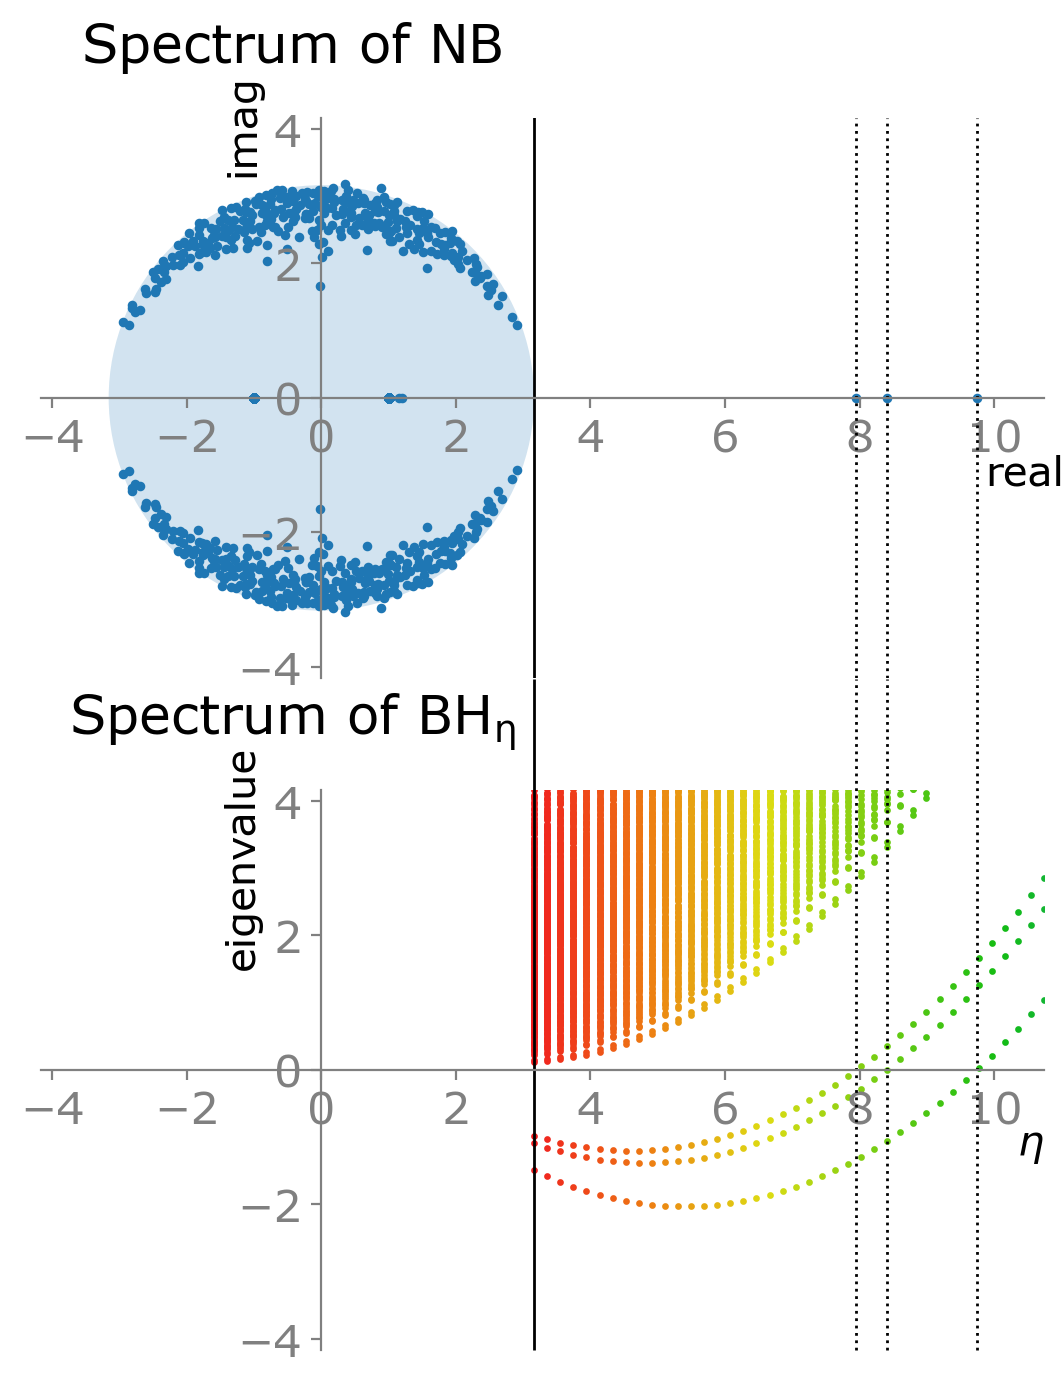

In [19]:
plot_spectral_NBBH(net, bulk=np.sqrt(d), ylabel_coor1=(0.22, 1.08), ylabel_coor2=(0.22, 1.08), eigBH_amplify=5)
save_path = "./_Figure/Hyper/" + "FigureNBBHspectrum_SBM_v2thesis.pdf"
# plt.tight_layout()
plt.savefig(save_path, dpi=600)

# Plot BH eig for degree corrected

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from _SBMMatrix import *
from _FigureJiazeHelper import *
from matplotlib.patches import Ellipse, Circle
from _CommunityDetect import *

%load_ext autoreload
%autoreload 2

In [2]:
def plot_matrix(A, ax):
    ax.spy(A, markersize=.5, rasterized=True)
    ax.set_xticks([])
    ax.set_yticks([])
    ax.set_xlabel('')

In [11]:
def plot_NB_eigenvalues(sbm, fig, ax, bulk=None, eig_B=None, ylabel_coor1=(0.25,0.95), ylabel_coor2=(0.2,0.95), 
                       title_x=0.25, xlabel_x=1.02):
    d = sbm.A.sum(axis=1).flatten().astype(float)
    d = np.sum(d)/np.shape(sbm.A)[0]
    if eig_B is None:
        NB = sbm.get_operator('NB')
        print(np.shape(NB))
        eig_B, _ = eig(NB.toarray())
    info_eig = []
    if bulk is None:
        bulk = np.sqrt(d)
    for e in eig_B:
        if abs(e) > bulk and e.imag == 0:
            info_eig.append(e)
    print(info_eig)
    scatter_spectral(eig_B, fig=fig, ax=ax, title=r"Spectrum of $\mathrm{NB}$", title_x=title_x)
    ax.add_patch(Circle(xy = (0.0, 0.0), radius=bulk, alpha=0.2))
    # ax.set_ylim(-bulk-1, 1 * bulk + 1)
    # ax.set_xlim(-bulk-1, max(info_eig).real+1)
    left, right = ax.get_xlim()
    for e in info_eig:
        ax.axvline(e.real, c='black', ls=':', lw=1)
    ax.axvline(bulk, c='black', ls='-', lw=1)
    ax.set_xlabel('real', loc='right', size=15)
    ax.set_ylabel('imag', loc='top', size=15, rotation=0)
    ax.yaxis.set_label_coords(ylabel_coor1[0],ylabel_coor1[1])
    ax.xaxis.set_label_coords(xlabel_x, 0.45)
    y_locs, y_ticks = plt.yticks()
    x_locs, x_ticks = plt.xticks()
    ax.set_aspect('equal',adjustable='box')
    ax.apply_aspect()
    return info_eig

In [23]:
def plot_BH_eigenvalues(A, ax, k=27, length=50, xlabel_x=1, xlabel_y=0.25, title_x=0.25):
    d = A.sum(axis=1).flatten().astype(float)
    rho = np.sum(d**2) / np.sum(d)
    border = np.sqrt(rho)
    average_d = np.sum(d)/np.shape(A)[0]
    print(f"border={border}, d={average_d}")
    # rs = np.hstack([np.linspace(-1, -int(border)-1, length), np.linspace(1, int(border)+1, length)])
    rs = np.hstack([np.linspace(-1, -int(average_d)-1, length), np.linspace(1, int(average_d)+1, length)])
    ws = np.zeros((np.size(rs), k))
    # TODO show many eigens
    i = 0
    for r in rs:
        B = eye(A.shape[0]).dot(r**2 - 1) - r * A + diags(d, 0)
        w, _ = eigsh(B, k, which='SA')
        w = np.sort(w)  # exclude 1st eigenvalue
        w = np.around(w, decimals=3)
        ws[i, :] = w
        i += 1
        # if i % 5 == 0:
        #     print("r:"+str(r), "eigenvalues:"+str(w))
    max_eig = np.max(ws)
    ws = ws / max_eig * border
    print("length of rs", len(rs))
    # print("lambda_0", x1)
    # print("lambda_1", x2)
    # print("lambda_2", x3)
    ax.spines['top'].set_color('none')
    ax.spines['right'].set_color('none')
    ax.xaxis.set_ticks_position('bottom')
    ax.spines['bottom'].set_position(('data', 0))
    ax.yaxis.set_ticks_position('left')
    ax.spines['left'].set_position(('data', 0))
    for i in range(k-1):
        ax.scatter(rs, ws[:, i], s=1, label=f"{i+1} th")
    ax.set_xlabel(r'$\eta$', size=15)
    ax.xaxis.set_label_coords(xlabel_x, xlabel_y)
    ax.set_title(r"Spectrum of $\mathrm{BH}_{\eta}$", x=title_x, y=1.07, size=18)
    plt.axvline(border, color='k', lw=1, label=r"$r$")
    plt.axvline(-border, color='k', lw=1, label=r"$-r$")
    ax.legend(loc=2, bbox_to_anchor=(1.05, 1.0), fontsize=10, markerscale=2)
    return max_eig

pin=0.09090909090909091, pout=0.004545454545454546
border=3.3453187213185176, d=10.253333333333334
r:-1.816326530612245 eigenvalues:[1.675 2.185 2.273 2.383 2.459]
r:-2.836734693877551 eigenvalues:[0.481 1.177 1.353 1.745 1.899]
r:-3.857142857142857 eigenvalues:[1.075 1.894 2.164 2.762 3.056]
r:-4.877551020408164 eigenvalues:[3.639 4.623 4.949 5.746 6.191]
r:-5.8979591836734695 eigenvalues:[ 8.229  9.41   9.766 10.763 11.35 ]
r:-6.918367346938775 eigenvalues:[14.87  16.266 16.639 17.836 18.544]
r:-7.938775510204081 eigenvalues:[23.575 25.194 25.58  26.974 27.792]
r:-8.959183673469388 eigenvalues:[34.349 36.197 36.597 38.183 39.107]
r:-9.979591836734695 eigenvalues:[47.198 49.275 49.692 51.467 52.494]
r:-11.0 eigenvalues:[62.123 64.43  64.868 66.827 67.958]
r:1.816326530612245 eigenvalues:[-6.505 -4.056 -3.584  2.136  2.365]
r:2.836734693877551 eigenvalues:[-13.125  -9.104  -8.35    1.345   1.746]
r:3.857142857142857 eigenvalues:[-17.754 -12.188 -11.121   2.263   2.748]
r:4.877551020408

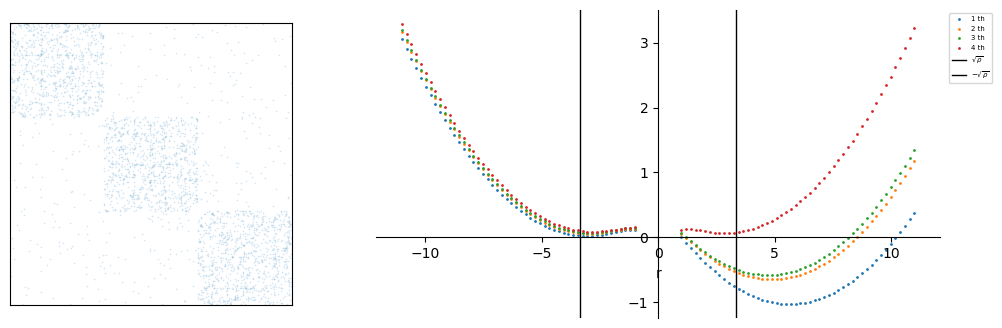

In [39]:
# Symmetric
n = 300
k = 3
d = 10
epsilon = 0.05
net = SymmetricSBM.init_epsc(n, k, d, epsilon)

fig = plt.figure(figsize=(12, 4))
widths = [4, 8]
heights = [4]
spec5 = fig.add_gridspec(ncols=2, nrows=1, width_ratios=widths, height_ratios=heights)
row = 0
col = 0
ax = fig.add_subplot(spec5[row, col])
plot_matrix(net.A.toarray(), ax)

row = 0
col = 1
ax = fig.add_subplot(spec5[row, col])
plot_BH_eigenvalues(net.A, ax, k=5, length=50)

pin=0.0024390243902439024, pout=0.04878048780487805
border=3.324972815193665, d=9.98
r:-1.7346938775510203 eigenvalues:[1.117 1.278 1.749 2.079 2.235]
r:-2.6530612244897958 eigenvalues:[-0.909 -0.389  0.544  0.966  1.518]
r:-3.5714285714285716 eigenvalues:[-1.485 -0.597  0.741  1.235  2.047]
r:-4.4897959183673475 eigenvalues:[-0.459  0.799  2.534  3.062  4.124]
r:-5.408163265306123 eigenvalues:[2.211 3.843 5.97  6.511 7.83 ]
r:-6.326530612244898 eigenvalues:[ 6.545  8.549 11.067 11.611 13.192]
r:-7.244897959183674 eigenvalues:[12.549 14.929 17.835 18.377 20.222]
r:-8.16326530612245 eigenvalues:[20.231 22.985 26.277 26.817 28.927]
r:-9.081632653061225 eigenvalues:[29.592 32.721 36.397 36.936 39.311]
r:-10.0 eigenvalues:[40.634 44.139 48.196 48.737 51.375]
r:1.7346938775510203 eigenvalues:[-5.714  1.9    2.015  2.149  2.35 ]
r:2.6530612244897958 eigenvalues:[-11.704   0.64    1.09    1.377   1.782]
r:3.5714285714285716 eigenvalues:[-16.113   0.801   1.465   2.042   2.396]
r:4.48979591836

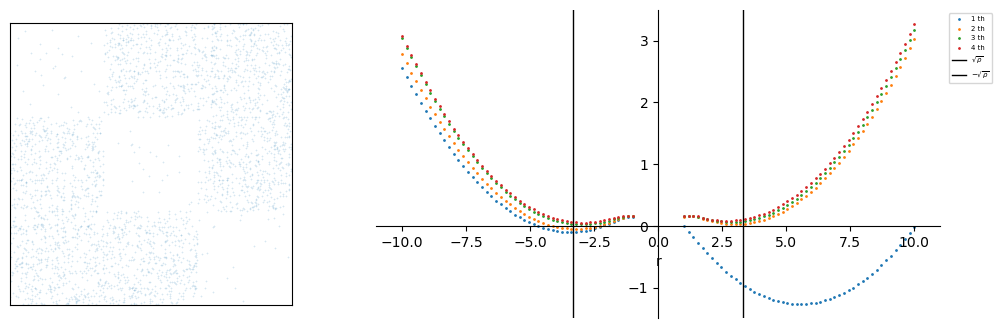

In [40]:
# Symmetric
n = 300
k = 3
d = 10
epsilon = 1/0.05
net = SymmetricSBM.init_epsc(n, k, d, epsilon)

fig = plt.figure(figsize=(12, 8))
widths = [4, 8]
heights = [4, 4]
spec5 = fig.add_gridspec(ncols=2, nrows=2, width_ratios=widths, height_ratios=heights)
row = 0
col = 0
ax = fig.add_subplot(spec5[row, col])
plot_matrix(net.A.toarray(), ax)

row = 0
col = 1
ax = fig.add_subplot(spec5[row, col])
plot_BH_eigenvalues(net.A, ax, k=5, length=50)

# Try DCSBM assortative

[[1.04738396 1.0446981  1.040566   ... 1.04542231 1.0474982  1.04542231]
 [1.0446981  1.04201912 1.03789762 ... 1.04274147 1.04481205 1.04274147]
 [1.040566   1.03789762 1.03379242 ... 1.03861711 1.0406795  1.03861711]
 ...
 [1.04542231 1.04274147 1.03861711 ... 1.04346432 1.04553633 1.04346432]
 [1.0474982  1.04481205 1.0406795  ... 1.04553633 1.04761246 1.04553633]
 [1.04542231 1.04274147 1.03861711 ... 1.04346432 1.04553633 1.04346432]]
[[0.         0.0522349  0.0520283  ... 0.01045422 0.01047498 0.01045422]
 [0.0522349  0.         0.05189488 ... 0.01042741 0.01044812 0.01042741]
 [0.0520283  0.05189488 0.         ... 0.01038617 0.01040679 0.01038617]
 ...
 [0.01045422 0.01042741 0.01038617 ... 0.         0.05227682 0.05217322]
 [0.01047498 0.01044812 0.01040679 ... 0.05227682 0.         0.05227682]
 [0.01045422 0.01042741 0.01038617 ... 0.05217322 0.05227682 0.        ]]


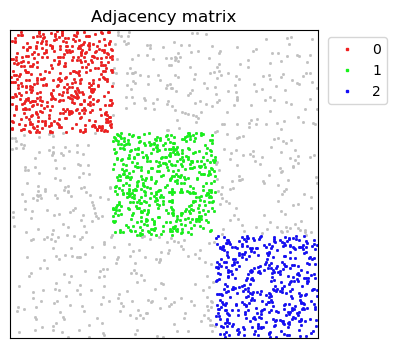

In [101]:
sizes = [100, 100, 100]
pin = 0.05
pout1 = 0.01
pout2 = 0.01
ps = [[pin, pout1, pout2], [pout1, pin, pout2], [pout2, pout2, pin]]
ps = np.array(ps)
lam = 100
sbm = DCSBM(sizes, ps, lam)
d = np.sum(sbm.A) / np.sum(sizes)

fig = plt.figure(figsize=(4, 4))
widths = [4]
heights = [4]
spec5 = fig.add_gridspec(ncols=1, nrows=1, width_ratios=widths, height_ratios=heights)
row = 0
col = 0
ax = fig.add_subplot(spec5[row, col])
c = gen_colors(start=colors_red[0], end=colors_blue[0], n=len(sbm.sizes))
plot_block_matrix(sbm.A.toarray(), partition_names=list(range(len(sbm.sizes))), partition_counts=sbm.sizes, colors=c)

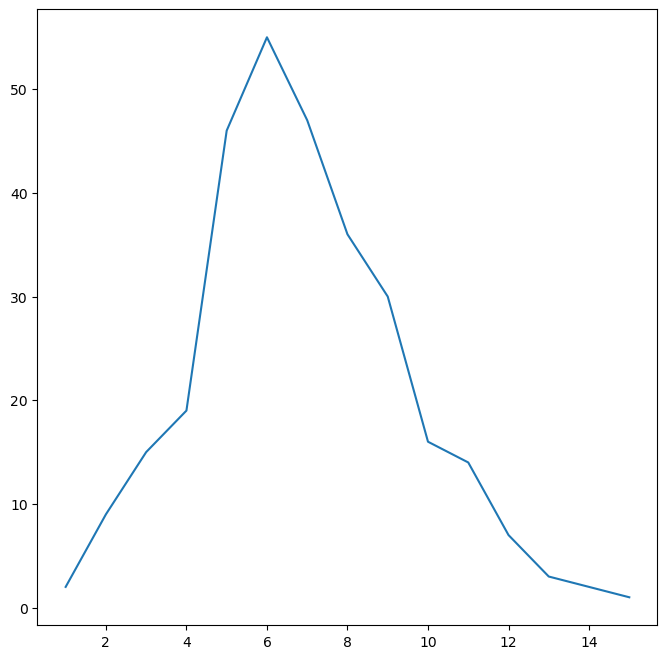

In [102]:
d, dis = np.unique(sbm.A.sum(1), return_counts=True)
plt.plot(d, dis)

In [134]:
d = sbm.A.sum(axis=1).flatten().astype(float)
rho = np.sum(d**2) / np.sum(d)
border = np.sqrt(rho)
k=5

(2040, 2040)
[(6.708495140354587+0j), (3.9691917938077665+0j), (3.476161710195431+0j)]
border=2.772236302634943, d=6.8
r:-1.489795918367347 eigenvalues:[0.961 1.108 1.172 1.315 1.322]
r:-2.1020408163265305 eigenvalues:[0.423 0.683 0.691 0.868 0.983]
r:-2.7142857142857144 eigenvalues:[0.447 0.689 0.823 0.936 1.121]
r:-3.326530612244898 eigenvalues:[1.135 1.309 1.596 1.759 1.921]
r:-3.9387755102040813 eigenvalues:[2.519 2.627 3.074 3.301 3.435]
r:-4.551020408163265 eigenvalues:[4.586 4.704 5.277 5.548 5.694]
r:-5.163265306122449 eigenvalues:[7.347 7.549 8.212 8.51  8.706]
r:-5.775510204081632 eigenvalues:[10.835 11.142 11.882 12.203 12.466]
r:-6.387755102040816 eigenvalues:[15.062 15.479 16.291 16.637 16.971]
r:-7.0 eigenvalues:[20.03  20.561 21.441 21.815 22.221]
r:1.489795918367347 eigenvalues:[-2.313  0.422  0.598  0.988  1.205]
r:2.1020408163265305 eigenvalues:[-4.746 -0.609 -0.355  0.318  0.774]
r:2.7142857142857144 eigenvalues:[-6.507 -1.112 -0.641  0.231  0.861]
r:3.32653061224489

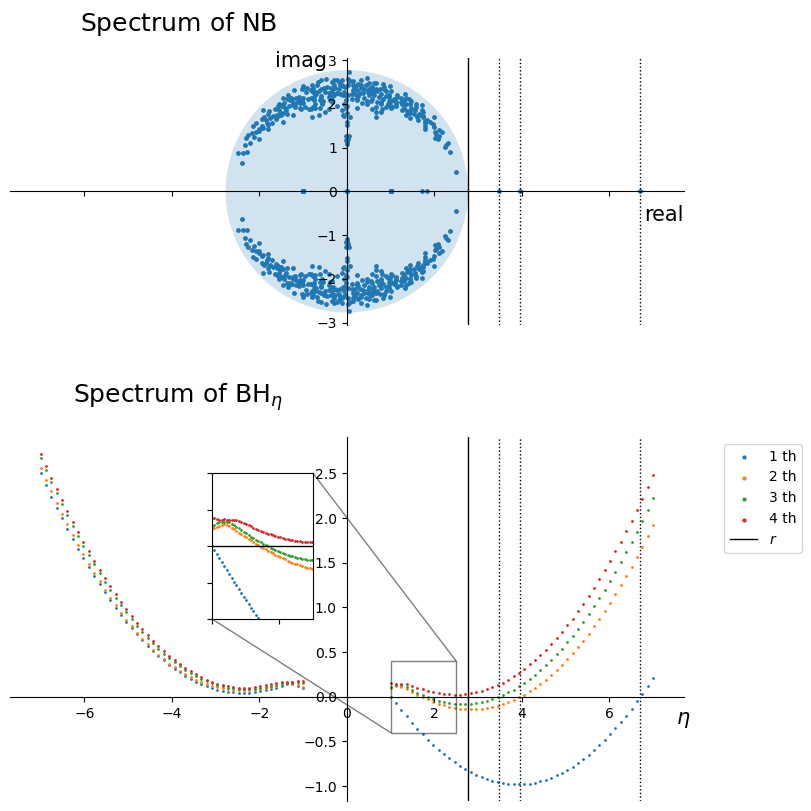

In [184]:
f, (ax1, ax2) = plt.subplots(2, 1, sharex=True, layout='constrained', figsize=(8, 8))

info_eig = plot_NB_eigenvalues(sbm, fig=f, ax=ax1, bulk=border, eig_B=None, ylabel_coor1=(0.47, 0.95), xlabel_x=1)

max_bh_eig = plot_BH_eigenvalues(sbm.A, ax2, k=k, length=50)

for e in info_eig:
    ax2.axvline(e.real, c='black', ls=':', lw=1)

x1, x2, y1, y2 = 1, 2.5, -0.4, 0.4  # subregion of the original image
axins = ax2.inset_axes(
    [0.3, 0.5, 0.15, 0.4],
    xlim=(x1, x2), ylim=(y1, y2), xticklabels=[], yticklabels=[])
# axins.imshow(Z2, extent=extent, origin="lower")
ax2.indicate_inset_zoom(axins, edgecolor="black")
rs = np.linspace(1, border, 50)
ws = np.zeros((np.size(rs), k))
i = 0
for r in rs:
    B = eye(sbm.A.shape[0]).dot(r**2 - 1) - r * sbm.A + diags(d, 0)
    w, _ = eigsh(B, k, which='SA')
    w = np.sort(w)  # exclude 1st eigenvalue
    w = np.around(w, decimals=3)
    ws[i, :] = w
    i += 1
ws = ws / max_bh_eig * border
for i in range(k-1):
    axins.scatter(rs, ws[:, i], s=1, label=f"{i+1} th")
axins.axhline(0, color='k', lw=1, label=r"$0$")

save_path = "./_Figure/Thesis/" + "FigureNBBHspectrum_DCSBM_thesis.pdf"
# plt.tight_layout()
plt.savefig(save_path, dpi=600)

In [97]:
dc_partition, dc_numgrou, zetas = CommunityDetect(sbm.A).DCBetheHessian()
d = sbm.A.sum(axis=1).flatten().astype(float)
rho = np.sum(d * d) / np.sum(d)
border = np.sqrt(rho)
print(zetas, border)

number of groups = 3
border 3.356802137469808 Kpos 3 Kneg 0
In positive case, Find 2th eigenvalue = 0 of BH with $\zeta$=1.428810252184906
In positive case, Find 3th eigenvalue = 0 of BH with $\zeta$=1.4968502552991159
[2, 1.428810252184906, 1.4968502552991159] 3.356802137469808


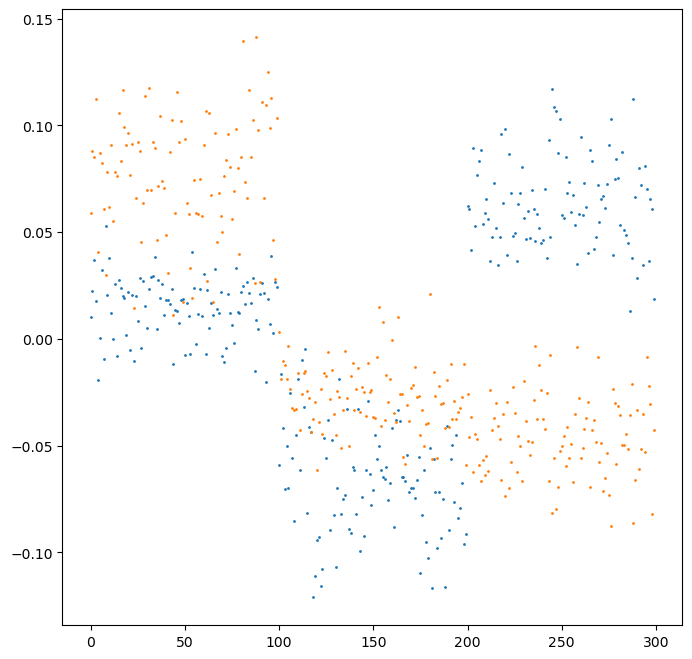

In [98]:
# bh
bh = BetheHessian(sbm.A, r=border, regularizer='BHa')
q = bh.find_negative_eigenvectors()
plt.scatter(np.arange(300), bh.evecs[:, 1], s=1)
plt.scatter(np.arange(300), bh.evecs[:, 2], s=1)

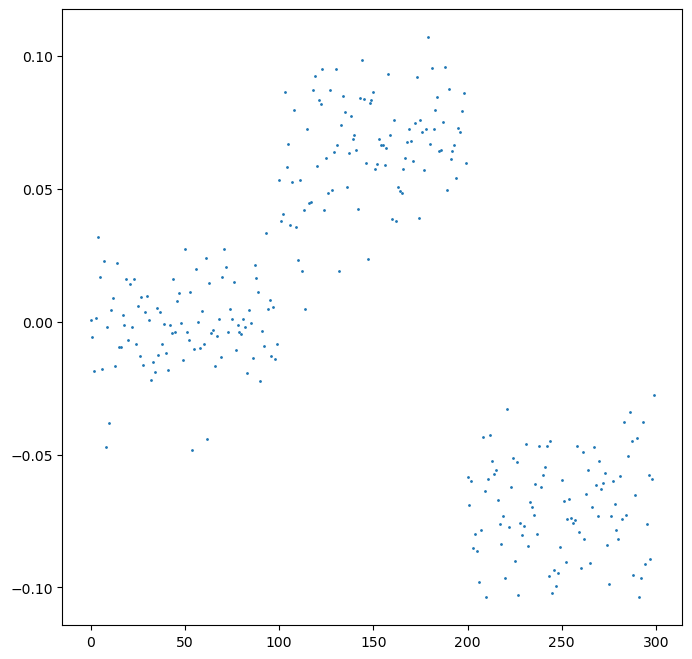

In [99]:
bh = BetheHessian(sbm.A, r=zetas[1], regularizer='BHa')
q = bh.find_k_eigenvectors(3)
plt.scatter(np.arange(300), bh.evecs[:, 1], s=1)

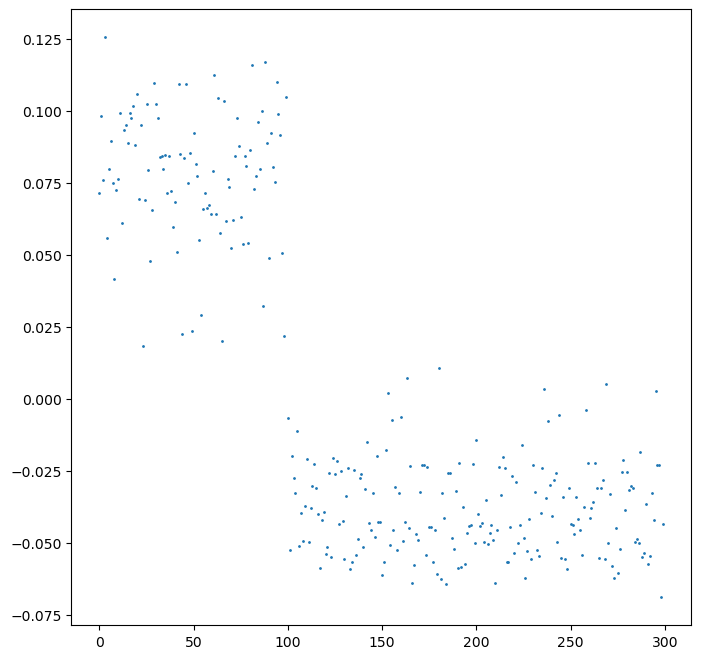

In [100]:
bh = BetheHessian(sbm.A, r=zetas[2], regularizer='BHa')
q = bh.find_k_eigenvectors(3)
plt.scatter(np.arange(300), bh.evecs[:, 2], s=1)

# Try DCSBM disassortative

[[1.04678209 1.04617023 1.0420912  ... 1.04382941 1.04624172 1.04483454]
 [1.04617023 1.04555874 1.04148209 ... 1.04321928 1.04563018 1.04422382]
 [1.0420912  1.04148209 1.03742133 ... 1.03915175 1.04155326 1.04015238]
 ...
 [1.04382941 1.04321928 1.03915175 ... 1.04088506 1.04329057 1.04188735]
 [1.04624172 1.04563018 1.04155326 ... 1.04329057 1.04570164 1.04429518]
 [1.04483454 1.04422382 1.04015238 ... 1.04188735 1.04429518 1.04289061]]
[[0.         0.0104617  0.01042091 ... 0.10438294 0.10462417 0.10448345]
 [0.0104617  0.         0.01041482 ... 0.10432193 0.10456302 0.10442238]
 [0.01042091 0.01041482 0.         ... 0.10391518 0.10415533 0.10401524]
 ...
 [0.10438294 0.10432193 0.10391518 ... 0.         0.01043291 0.01041887]
 [0.10462417 0.10456302 0.10415533 ... 0.01043291 0.         0.01044295]
 [0.10448345 0.10442238 0.10401524 ... 0.01041887 0.01044295 0.        ]]


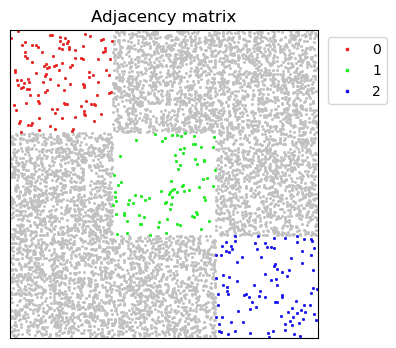

In [15]:
sizes = [100, 100, 100]
pin = 0.01
pout1 = 0.1
pout2 = 0.1
ps = [[pin, pout1, pout2], [pout1, pin, pout2], [pout2, pout2, pin]]
ps = np.array(ps)
lam = 100
dcsbm_dis = DCSBM(sizes, ps, lam)

fig = plt.figure(figsize=(4, 4))
widths = [4]
heights = [4]
spec5 = fig.add_gridspec(ncols=1, nrows=1, width_ratios=widths, height_ratios=heights)
row = 0
col = 0
ax = fig.add_subplot(spec5[row, col])
c = gen_colors(start=colors_red[0], end=colors_blue[0], n=len(dcsbm_dis.sizes))
plot_block_matrix(dcsbm_dis.A.toarray(), partition_names=list(range(len(dcsbm_dis.sizes))), partition_counts=dcsbm_dis.sizes, colors=c)

In [16]:
d = dcsbm_dis.A.sum(axis=1).flatten().astype(float)
rho = np.sum(d**2) / np.sum(d)
border = np.sqrt(rho)
k=5

In [24]:
NB = dcsbm_dis.get_operator('NB')
eig_B, _ = eig(NB.toarray())

(6638, 6638)
[(21.986014341451785+0j), (-9.248303192492845+0j), (-8.703088653902602+0j)]
border=4.797653086991117, d=22.126666666666665
r:-2.795918367346939 eigenvalues:[-2.778 -1.489  4.277  5.087  6.322]
r:-5.040816326530612 eigenvalues:[-11.123  -9.002   2.646   3.651   5.609]
r:-7.285714285714286 eigenvalues:[-9.569 -6.645 10.785 12.006 14.457]
r:-9.53061224489796 eigenvalues:[ 2.008  5.731 28.911 30.36  33.268]
r:-11.775510204081632 eigenvalues:[23.641 28.162 57.075 58.759 62.11 ]
r:-14.020408163265307 eigenvalues:[ 55.34   60.66   95.298  97.22  101.009]
r:-16.26530612244898 eigenvalues:[ 97.111 103.229 143.586 145.75  149.974]
r:-18.510204081632654 eigenvalues:[148.957 155.872 201.946 204.352 209.009]
r:-20.755102040816325 eigenvalues:[210.878 218.591 270.379 273.03  278.118]
r:-23.0 eigenvalues:[282.876 291.387 348.887 351.783 357.301]
r:2.795918367346939 eigenvalues:[-33.979   4.864   5.439   5.524   6.198]
r:5.040816326530612 eigenvalues:[-67.94    3.061   4.318   4.905   5.7

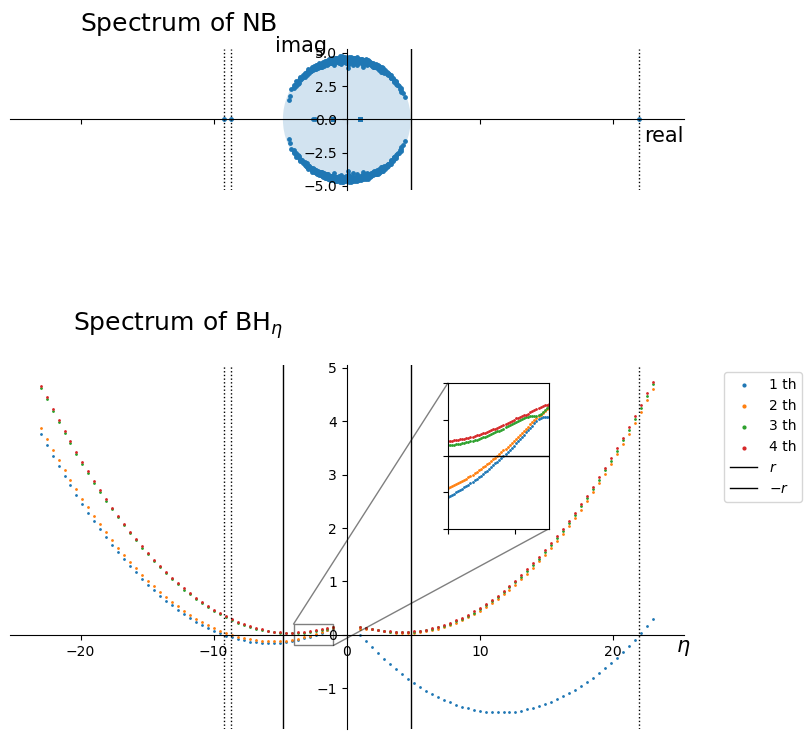

In [22]:
f, (ax1, ax2) = plt.subplots(2, 1, sharex=True, layout='constrained', figsize=(8, 8))

info_eig = plot_NB_eigenvalues(dcsbm_dis, fig=f, ax=ax1, bulk=border, eig_B=eig_B, ylabel_coor1=(0.47, 0.95), xlabel_x=1)

max_bh_eig = plot_BH_eigenvalues(dcsbm_dis.A, ax2, k=k, length=50)

for e in info_eig:
    ax2.axvline(e.real, c='black', ls=':', lw=1)

x1, x2, y1, y2 = -4, -1, -0.2, 0.2  # subregion of the original image
axins = ax2.inset_axes(
    [0.65, 0.55, 0.15, 0.4],
    xlim=(x1, x2), ylim=(y1, y2), xticklabels=[], yticklabels=[]) # 
# axins.imshow(Z2, extent=extent, origin="lower")
ax2.indicate_inset_zoom(axins, edgecolor="black")
rs = np.linspace(-4, -1, 50)
ws = np.zeros((np.size(rs), k))
i = 0
for r in rs:
    B = eye(dcsbm_dis.A.shape[0]).dot(r**2 - 1) - r * dcsbm_dis.A + diags(d, 0)
    w, _ = eigsh(B, k, which='SA')
    w = np.sort(w)  # exclude 1st eigenvalue
    w = np.around(w, decimals=3)
    ws[i, :] = w
    i += 1
ws = ws / max_bh_eig * border
for i in range(k-1):
    axins.scatter(rs, ws[:, i], s=1, label=f"{i+1} th")
axins.axhline(0, color='k', lw=1, label=r"$0$")

save_path = "./_Figure/Thesis/" + "FigureNBBHspectrum_DCSBM_disassort_thesis.pdf"
# plt.tight_layout()
plt.savefig(save_path, dpi=600)

# Bipartite & One-mode projection Community Illustration

In [5]:
def symBSBM(n1=100, q1=2, delta=0.02, d=1, showMat=False, verbose=True):
    n2 = n1
    q2 = q1
    sizes = [int(n1 / q1)] * q1 + [int(n2 / q2)] * q2
    a = d/n1-delta/q1+delta
    b = d/n1-delta/q1
    if a < 0 or a > 1 or b < 0 or b > 1:
        return None, None, None, None, None
    print(f'a={a}, b={b}') if verbose else None
    H = (a - b) * np.identity(q1) + b * np.ones((q1, q2))
    bsbm = BipartiteSBM(q1, q2, sizes, H)
    H_svalues = bsbm.getSingulars()
    print(H_svalues) if verbose else None
    snr_full = n1 / q1 * H_svalues[0]
    snr_sub1 = n1 / q1* H_svalues[1]**2 / H_svalues[0]
    print(f'SNR of full bipartite network is {snr_full}, the first partite is {snr_sub1}') if verbose else None
    partition, numgroups = CommunityDetect(bsbm.A).BetheHessian(num_groups=None)
    ami = adjusted_mutual_info_score(bsbm.groupId, partition)
    print(f'Detect {numgroups} communities, the AMI of partition is {ami}') if verbose else None
    if showMat:
        plt.figure(figsize=(1, 1), layout="constrained")
        plt.matshow(bsbm.A[:n1, n1:].toarray())
        plt.title("B")
    return bsbm, partition, numgroups, ami, snr_full, snr_sub1

a=0.1625, b=0.012500000000000004
[0.2  0.15 0.15 0.15]
SNR of full bipartite network is 5.0, the first partite is 2.8125000000000004
number of groups = 8, Kpos=4, Kneg=4
Detect 8 communities, the AMI of partition is 0.9056616432054594


D:\BackProgram\Anaconda\envs\network\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


<Figure size 100x100 with 0 Axes>

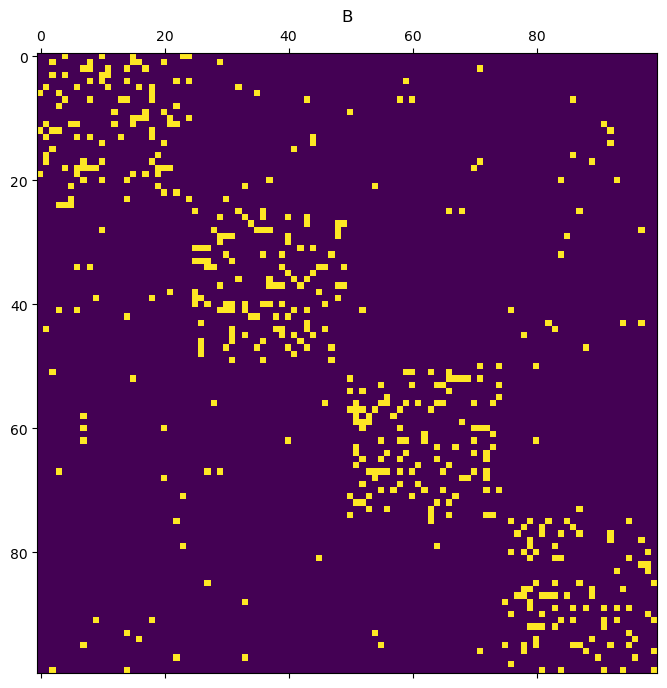

In [13]:
bsbm, partition, numgroups, ami, snr_full, snr_sub1 = symBSBM(n1=100, q1=4, delta=0.15,  d=5, showMat=True)

# Bipartite SBM NB spectrum distortion

In [88]:
from EXPERIMENT_BIPARTITE import generate_delta_range, generate_bsbm
import matplotlib.pyplot as plt
from _FigureJiazeHelper import *
from _SBMMatrix import *

%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [89]:
# Matplotlib settings

# plt.style.use('seaborn-whitegrid')
plt.rc('figure', figsize=(8, 5))
plt.rc('font', size=16)
plt.rc('font', family='sans-serif')
plt.rcParams['font.sans-serif'] = 'verdana'
plt.rcParams['lines.linewidth'] = 4
plt.rcParams['axes.spines.right'] = False
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.edgecolor'] = basic_line_color
plt.rcParams['xtick.color'] = basic_line_color
plt.rcParams['ytick.color'] = basic_line_color
plt.rcParams['axes.labelsize'] = 'large'
plt.rcParams['lines.markersize'] = 12

%config InlineBackend.figure_format = 'retina'

In [90]:
n1= n2 = 300
k1 = k2 = 3
d = 5
Htype = 0
min_delta, max_delta = generate_delta_range(n1, n2, k1, k2, d, Htype)
print(min_delta, max_delta)
delta = 0.04
bsbm = generate_bsbm(n1, n2, k1, k2, d, delta, Htype=0)
lambdas = bsbm.getSingulars()
print(f"SNR_H={n1/k1*lambdas[1]**2 / lambdas[0]}")

-0.025 0.05
--For symmetric case n1=300, k1=3, d=5, Range of delta (-0.025, 0.05). Now delta=0.04 which make p_diagonal_B=0.043333333333333335, p_offdiagonal_B=0.0033333333333333322
SNR_H=3.2000000000000024


In [91]:
omega_p = n2 * (1/3 * 0.043**2 + 2/3 * 0.003**2)
omega_q = n2 * (2/3 * 0.043 * 0.003 + 1/3 * 0.003**2)
print(omega_p, omega_q)

0.18669999999999998 0.026699999999999998


In [92]:
sizes = [100, 100, 100]
omegas = np.array([[0.187, 0.027, 0.027], [0.027, 0.187, 0.027], [0.027, 0.027, 0.187]])
sbm = PoissonSBM(sizes, omegas)
d = np.sum(sbm.A) / np.sum(sizes)

0it [00:00, ?it/s]D:\Work\PhD\_code\_nodeclassification\_SBMMatrix.py:233: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  self.A[index] = w
44850it [00:00, 52600.62it/s]


In [93]:
def plot_spectral_WNB(weighted_matrix, NB=None, eig_NB=None, fig=None, ax=None, title=""):
    R = np.sqrt((weighted_matrix**2).sum() / weighted_matrix.shape[0])
    if NB is None:
        NB = BipartiteSBM.get_projection_operator(projection_matrix=weighted_matrix, operator='WNB')
    print(np.shape(NB), NB.sum())
    if eig_NB is None:
        eig_NB, _ = eig(NB.toarray())
    info_eig = []
    for e in eig_NB:
        if abs(e) > R and e.imag == 0:
            info_eig.append(e)
    print(info_eig)
    if fig is None and ax is None:
        fig = plt.figure(figsize=(8, 4))
        widths = [5]
        heights = [5]
        spec5 = fig.add_gridspec(ncols=1, nrows=1, width_ratios=widths, height_ratios=heights)
        row = 0
        col = 0
        ax = fig.add_subplot(spec5[row, col])
    scatter_spectral(eig_NB, fig=fig, ax=ax, title=title, title_x=0.5, node_size=5)
    ax.add_patch(Circle(xy = (0.0, 0.0), radius=R, alpha=0.2))

In [95]:
AA = bsbm.A.dot(bsbm.A)
AA = AA - diags(np.diag(AA.toarray()), 0)
proj_n1_A = AA[:n1, :n1].toarray()
WNB_proj = BipartiteSBM.get_projection_operator(projection_matrix=proj_n1_A, operator='WNB')
eig_WNB_proj, _ = eig(WNB_proj.toarray())

In [96]:
WNB_PSBM = BipartiteSBM.get_projection_operator(projection_matrix=sbm.A.toarray(), operator='WNB')
eig_WNB_PSBM, _ = eig(WNB_PSBM.toarray())

(7138, 7138) 210683.0
[(29.961342114000946+0j), (21.57422930271572+0j), (19.14048898082387+0j), (11.165933384632787+0j), (10.73433350005331+0j), (9.718910953541453+0j), (8.76771236977131+0j), (8.351792874116573+0j), (7.726073317458287+0j), (6.7083029429029635+0j), (6.496354588017833+0j), (6.3644337281801056+0j)]
(6602, 6602) 154928.0
[(23.526634119410573+0j), (15.563382535980342+0j), (14.511332527932218+0j)]


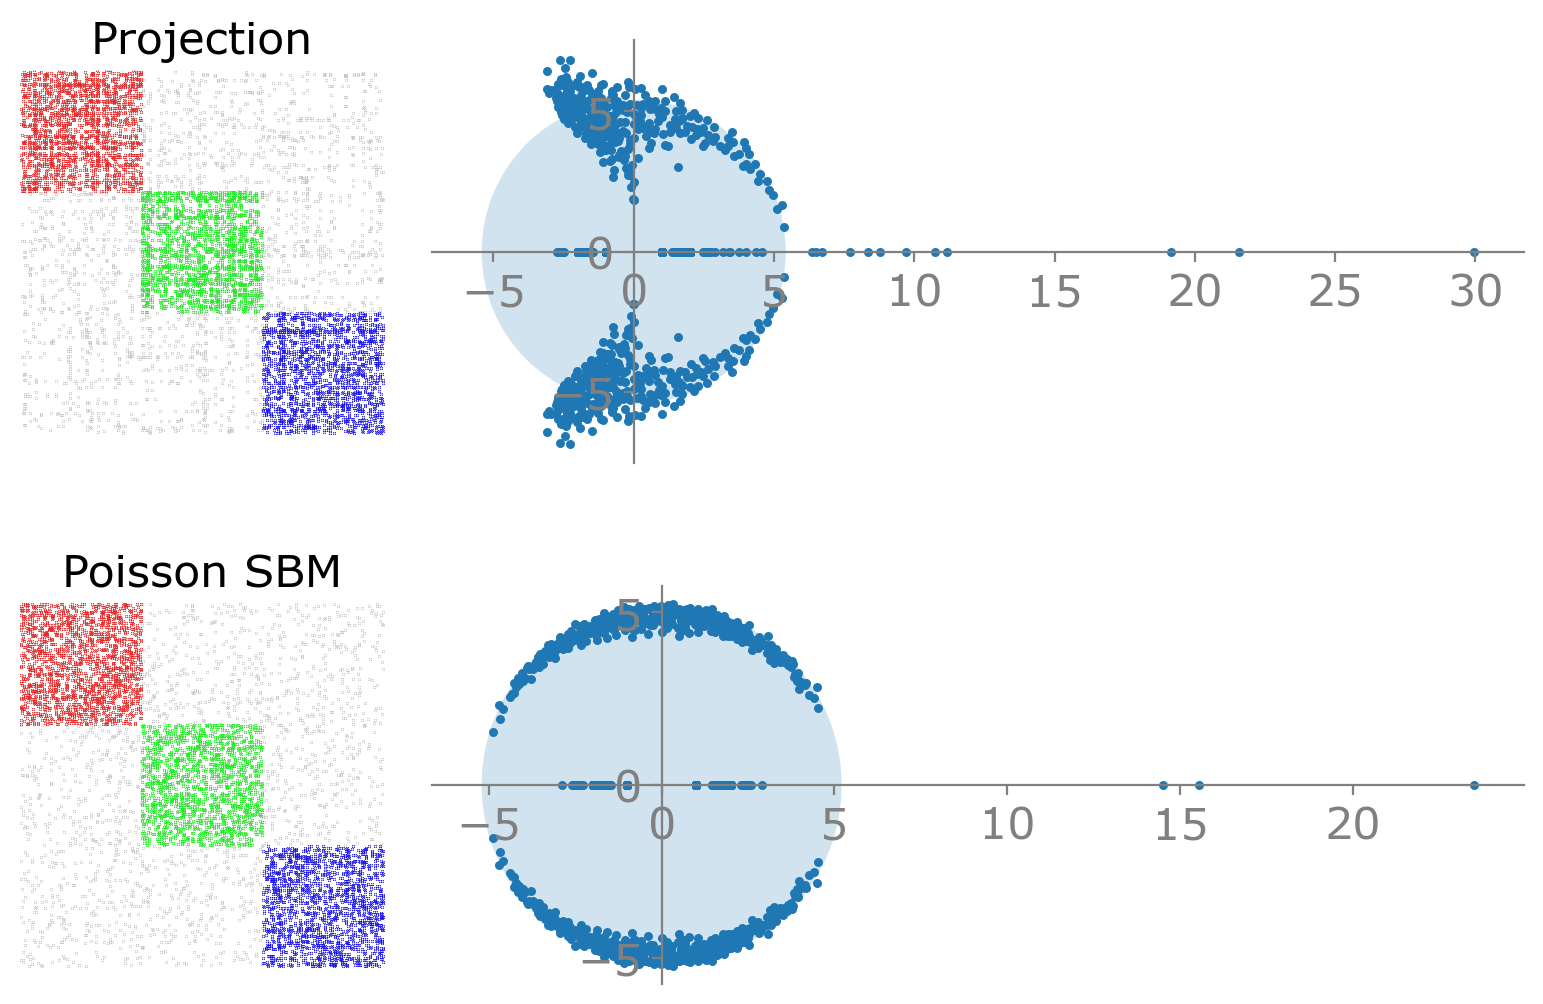

In [97]:
# fig = plt.figure(figsize=(8, 8))
# widths = [4, 6]
# heights = [4, 4]
# spec5 = fig.add_gridspec(ncols=2, nrows=2, width_ratios=widths, height_ratios=heights)
# row = 0
# col = 0
# ax = fig.add_subplot(spec5[row, col])
fig, axes = plt.subplots(nrows=2, ncols=2, figsize=(8, 6), 
                         gridspec_kw={'width_ratios': [1, 3], 'height_ratios': [2, 2]}, 
                        ) 
ax = axes[0, 0]
plt.sca(ax)
c = gen_colors(start=colors_red[0], end=colors_blue[0], n=k1)
plot_block_matrix(proj_n1_A, partition_names=list(range(k1)), partition_counts=sizes,
                  colors=c, ms=0.01,  label=r"One-mode Projection", show_legend=False)
ax.set_title(r"Projection", fontsize=16)
ax.spines['left'].set_visible(False)
ax.spines['bottom'].set_visible(False)

# row = 1
# col = 0
# ax = fig.add_subplot(spec5[row, col])
ax = axes[1, 0]
plt.sca(ax)
c = gen_colors(start=colors_red[0], end=colors_blue[0], n=len(sbm.sizes))
plot_block_matrix(sbm.A.toarray(), partition_names=list(range(len(sbm.sizes))), partition_counts=sbm.sizes, 
                  colors=c, ms=0.01, label=r"Poisson SBM", show_legend=False)
ax.set_title(r"Poisson SBM", fontsize=16)
ax.spines['left'].set_visible(False)
ax.spines['bottom'].set_visible(False)

# row = 0
# col = 1
# ax1 = fig.add_subplot(spec5[row, col])
ax = axes[0, 1]
plot_spectral_WNB(proj_n1_A, NB=WNB_proj, eig_NB=eig_WNB_proj, fig=fig, ax=ax)

# row = 1
# col = 1
# ax = fig.add_subplot(spec5[row, col])
ax = axes[1, 1]
plot_spectral_WNB(sbm.A.toarray(), NB=WNB_PSBM, eig_NB=eig_WNB_PSBM, fig=fig, ax=ax)

plt.tight_layout()

save_path = f"./_Figure/Thesis/" + f"Figure5.2_DistortSpectrumNB_OneModeProj.pdf"
plt.savefig(save_path, dpi=600)

# Bipartite Detectability (Both N and N_1)

In [77]:
from EXPERIMENT_BIPARTITE_2025 import read_exp, symBSBM
from _FigureJiazeHelper import *
import matplotlib.pyplot as plt
from matplotlib.patches import Ellipse, Circle
from matplotlib.colors import LinearSegmentedColormap, ListedColormap
from scipy.sparse import find
from scipy.sparse.linalg import eigs, eigsh
from scipy.linalg import eig
from _CommunityDetect import *
from spectralOperator import BetheHessian
from _HyperSBM import *
from _SBMMatrix import *
import warnings
from collections import Counter
warnings.filterwarnings('ignore', category=FutureWarning)

%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [2]:
# Matplotlib settings

# plt.style.use('seaborn-whitegrid')
plt.rc('figure', figsize=(8, 5))
plt.rc('font', size=16)
plt.rc('font', family='sans-serif')
plt.rcParams['font.sans-serif'] = 'verdana'
plt.rcParams['lines.linewidth'] = 4
plt.rcParams['axes.spines.right'] = False
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.edgecolor'] = basic_line_color
plt.rcParams['xtick.color'] = basic_line_color
plt.rcParams['ytick.color'] = basic_line_color
plt.rcParams['axes.labelsize'] = 'large'
plt.rcParams['lines.markersize'] = 12

%config InlineBackend.figure_format = 'retina'

In [108]:
n1=100
q1=2
max_d = 5
deltas = np.linspace(0, min((q1-q1/n1*max_d)/(q1-1), q1/n1*max_d), 41)
ds = np.hstack((np.linspace(0.5, 1, 21), np.linspace(1.2, max_d, 20)))
full_snrs = []
sub1_snrs = []
for d in tqdm(ds):
    for delta in deltas:
        n2 = n1
        q2 = q1
        sizes = [int(n1 / q1)] * q1 + [int(n2 / q2)] * q2
        a = d/n1-delta/q1+delta
        b = d/n1-delta/q1
        if a <= 1e-6 or a >= 1 or b <= 1e-6 or b >= 1:
            full_snrs.append(np.inf)
            sub1_snrs.append(np.inf)
            continue
        # print(f'a={a}, b={b}')
        H = (a - b) * np.identity(q1) + b * np.ones((q1, q2))
        bsbm = BipartiteSBM(q1, q2, sizes, H)
        H_svalues = bsbm.getSingulars()
        snr_full = n1 / q1 * H_svalues[0]
        snr_sub1 = n1 / q1* H_svalues[1]**2 / H_svalues[0]
        full_snrs.append(snr_full)
        sub1_snrs.append(snr_sub1)
full_snrs = np.array(full_snrs)
sub1_snrs = np.array(sub1_snrs)
tag = "symmetricB_acrossD=1"
fileID = 'amiExp25.2.1' + f'_n1={n1}_q1={q1}_{tag}'
save_path = "./result/detectabilityBipartite/" + fileID + ".txt"
add_fileIDs = ['amiExp25.8.15' + f'_n1={n1}_q1={q1}_{tag}']
add_paths = ["./result/detectabilityBipartite/" + fid + ".txt" for fid in add_fileIDs]
plot_ds, plot_deltas, Results = read_exp(load_path=save_path, add_paths=add_paths)
full_ami = [np.around(r[1], 1) + 0 for r in Results]
sub1_ami = [np.around(r[4], 1) + 0 for r in Results]
# full_ami = [100 if a==-1 else a for a in full_ami]
# sub1_ami = [100 if a==-1 else a for a in sub1_ami]
full_amis = np.array(full_ami)
sub1_amis = np.array(sub1_ami)

full_numgroup = [r[0] + 0 for r in Results]
sub1_numgroup = [r[3] + 0 for r in Results]
full_numgroups = np.array(full_numgroup)
sub1_numgroups = np.array(sub1_numgroup)

# full_snrs = np.array([r[2] + 0 for r in Results])
# sub1_snrs = np.array([r[5] + 0 for r in Results])

100%|██████████████████████████████████████████████████████████████████████████████████| 41/41 [00:01<00:00, 22.73it/s]


Additional result adding...


In [107]:
def color_imshow_2d_(x, y, z, title="", xlabel="", ylabel="", 
                         cmap=cm.coolwarm,
                         ax=None, fig=None, return_gridz=False, 
                         set_xticks=True, set_yticks=True, vmin=None, vmax=None, 
                         ytickprecision=5, cticks=None, 
                         show_colorbar=True, show_ext_color=False, top_cbar=False):
    norm_z = np.zeros(np.size(z))
    for i in range(np.size(z)):
        norm_z[i] = z[i]
    _x = np.sort(np.unique(x))
    _y = np.sort(np.unique(y))
    _z = np.zeros((np.size(_y), np.size(_x)))
    ori_z = np.zeros((np.size(_y), np.size(_x)))
    for i, zi in enumerate(norm_z):
        i_x = np.where(_x == x[i])
        i_y = np.where(_y == y[i])
        _z[i_y, i_x] = zi
        ori_z[i_y, i_x] = z[i]
    if return_gridz:
        return ori_z
    if ax is None or fig is None:
        fig = plt.figure(figsize=(10, 10))
        widths = [4]
        heights = [4]
        spec5 = fig.add_gridspec(ncols=1, nrows=1, width_ratios=widths, height_ratios=heights)
        row = 0
        col = 0
        ax = fig.add_subplot(spec5[row, col])
    if vmax is not None:
        norm_vmax = vmax
    else:
        norm_vmax = None
    if vmin is not None:
        norm_vmin = vmin
    else:
        norm_vmin = None
    im = ax.imshow(_z, cmap=cmap, origin='lower', vmin=norm_vmin, vmax=norm_vmax)
    ax.set_title(title, fontsize=16)
    ax.set_xlabel(xlabel, fontsize=16)
    ax.set_ylabel(ylabel, rotation='horizontal', fontsize=16)
    # ax.set_xlim(np.min(x), np.max(x))
    # ax.set_ylim(np.min(y), np.max(y))
    if set_xticks:
        ax.set_xticks(np.linspace(0, np.size(_x)-1, 3), np.around(np.linspace(np.min(x), np.max(x), 3), 3), fontsize=10)
    else:
        ax.set_xticks([])
    if set_yticks:
        yticks_num = 5  # int(np.size(np.unique(y)) / 2)
        ax.set_yticks(np.linspace(0, np.size(_y) - 1, yticks_num), np.around(np.linspace(np.min(y), np.max(y), yticks_num), ytickprecision), fontsize=10)
    else:
        ax.set_yticks([])
    if show_colorbar:
        divider = make_axes_locatable(ax)
        if top_cbar:
            cax = divider.append_axes("top", size="5%", pad=0.5)
        else:
            cax = divider.append_axes("right", size="5%", pad=0.05)
        if cticks is None:
            min_normz = np.min(norm_z)
            max_normz = np.max(norm_z)
            cticks = np.linspace(min_normz, max_normz, 5)
        clabels = [x for x in cticks]
        if show_ext_color:
            cbar = fig.colorbar(im, cax=cax, ticks=cticks, orientation="horizontal" if top_cbar else None, extend='both')
        else:
            cbar = fig.colorbar(im, cax=cax, ticks=cticks)
        cbar.ax.tick_params(labelsize=10)
        if top_cbar:
            cbar.ax.set_xticklabels(clabels)
        else:
            cbar.ax.set_yticklabels(clabels)
        cbar.outline.set(visible=False)
    return ori_z

minz=0, maxz=1, cticks=[0, 1], clabel=['0', '1']
minz=0, maxz=1, cticks=[0, 1], clabel=['0', '1']


D:\Work\PhD\_code\_nodeclassification\_FigureJiazeHelper.py:142: RuntimeWarning: invalid value encountered in scalar divide
  norm_z[i] = (z[i] - z_center) / (maxz - z_center) * max_linear_cmap/2 + max_linear_cmap/2


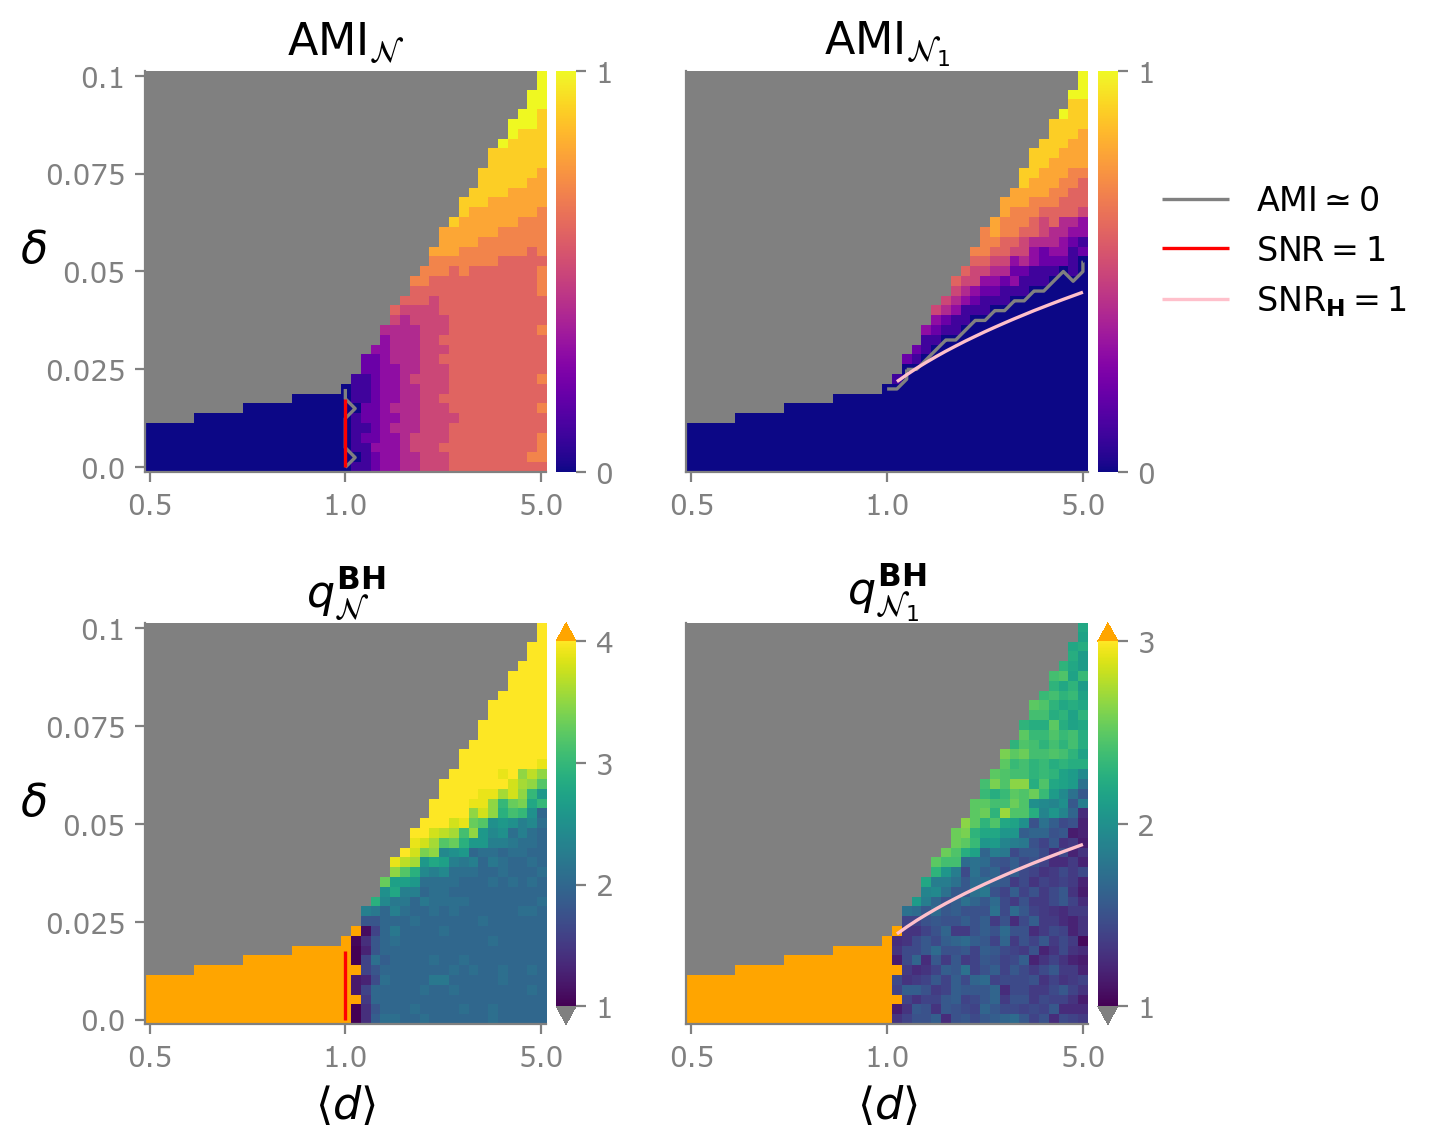

In [109]:
fig = plt.figure(figsize=(6.2, 6))
widths = [3, 3]
heights = [3, 3]
spec5 = fig.add_gridspec(ncols=2, nrows=2, width_ratios=widths, height_ratios=heights)
row = 0
col = 0
ax = fig.add_subplot(spec5[row, col])
handels = []
cmap = mpl.colormaps["plasma"]
cmap = cmap.with_extremes(bad="gray", under="gray", over="gray")
# print(cmap)
plot_fullami = color_imshow_2d(plot_ds, plot_deltas, full_amis, z_center=0.5, title=r"$\mathrm{AMI}_{\cal N}$", xlabel=r"", ylabel=r"$\delta$", 
                min_z=0, max_z=1, cmap=cmap, ax=ax, fig=fig, return_gridz=False, set_xticks=False, vmin=0, vmax=1, ytickprecision=3, cticks=[0, 1])
filtered_plot_fullami = np.where(np.abs(plot_fullami) < 0.5, plot_fullami, np.nan)
handels += contour_data(filtered_plot_fullami, ax, levels=[1e-4], fmt={1e-4: r'$\rm AMI$\simeq$0$'}, color='gray', inline=False)
xtickpos = np.linspace(0, np.size(ds)-1, 3)
xticks = [np.around(ds[int(xi)], 3) for xi in xtickpos]
ax.set_xticks(xtickpos, xticks, fontsize=10)
plot_fullsnr = color_imshow_2d(plot_ds, plot_deltas, full_snrs, z_center=1, min_z=0, max_z=np.max(full_snrs), return_gridz=True)
handels += contour_data(plot_fullsnr, ax, levels=[1], fmt={1: r'$\rm SNR=1$'}, color='red', inline=False)

row = 0
col = 1
ax = fig.add_subplot(spec5[row, col])
plot_sub1ami = color_imshow_2d(plot_ds, plot_deltas, sub1_amis, z_center=0.5, title=r"$\mathrm{AMI}_{\mathcal{N}_1}$", xlabel=r"", ylabel=r"", 
                min_z=0, max_z=1, cmap=cmap, ax=ax, fig=fig, return_gridz=False, set_xticks=False, set_yticks=False, vmin=0, vmax=1, ytickprecision=3,
                    cticks=[0, 1])
filtered_plot_sub1ami = np.where(np.abs(plot_sub1ami) < 0.5, plot_sub1ami, np.nan)
contour_data(filtered_plot_sub1ami, ax, levels=[1e-4], fmt={1e-4: r'$\rm AMI$\simeq$0$'}, color='gray', inline=False)
ax.set_xticks(xtickpos, xticks, fontsize=10)
plot_sub1snr = color_imshow_2d(plot_ds, plot_deltas, sub1_snrs, z_center=1, return_gridz=True)
handels += contour_data(plot_sub1snr, ax, levels=[1], fmt={1: r'$\rm SNR_{H}=1$'}, color='pink', inline=False)

row = 1
col = 0
ax = fig.add_subplot(spec5[row, col])
cmap = mpl.colormaps["viridis"]
# newcolors = cmap(np.linspace(0, 1, 256))
# pink = np.array([248/256, 24/256, 148/256, 1])
# newcolors[-25:, :] = pink
# newcmp = ListedColormap(newcolors)
cmap = cmap.with_extremes(bad="gray", under="gray", over="orange")
# print(cmap)
mask = (full_numgroups > 0) & (full_numgroups < 1)
full_numgroups[mask] = 1
plot_fullnumgroup = color_imshow_2d_(plot_ds, plot_deltas, full_numgroups, 
                                    title=r"$q^{\bf BH}_{\cal N}$", xlabel=r"$\left<d\right>$", ylabel=r"$\delta$",
                                    cmap=cmap, ax=ax, fig=fig, return_gridz=False, set_xticks=True,
                                    vmin=1, vmax=4,
                                    ytickprecision=3, show_ext_color=True,
                                    cticks=[1, 2, 3, 4])
ax.set_xticks(xtickpos, xticks, fontsize=10)
plot_fullsnr = color_imshow_2d(plot_ds, plot_deltas, full_snrs, z_center=1, min_z=0, max_z=np.max(full_snrs), return_gridz=True)
contour_data(plot_fullsnr, ax, levels=[1], fmt={1: r'$SNR_{full}=1$'}, color='red', inline=False)

row = 1
col = 1
ax = fig.add_subplot(spec5[row, col])
plot_sub1numgroup = color_imshow_2d_(plot_ds, plot_deltas, sub1_numgroups, 
                                     title=r"$q^{\bf BH}_{\mathcal{N}_1}$", xlabel=r"$\left<d\right>$", ylabel=r"", 
                                    cmap=cmap, ax=ax, fig=fig, return_gridz=False, 
                                     set_xticks=True, set_yticks=False, show_ext_color=True,
                                     vmin=1, vmax=3, ytickprecision=3, cticks=[1, 2, 3])
ax.set_xticks(xtickpos, xticks, fontsize=10)
plot_sub1snr = color_imshow_2d(plot_ds, plot_deltas, sub1_snrs, z_center=1, return_gridz=True)
contour_data(plot_sub1snr, ax, levels=[1], fmt={1: r'$SNR_{sub}=1$'}, color='pink', inline=False)

lgd = fig.legend(handels, [r'$\rm AMI\simeq 0$', r'$\rm SNR=1$', r'$\rm SNR_{\bf H}=1$'], loc=2, bbox_to_anchor=(0.94, 0.85),  fontsize=12, markerscale=2, frameon=False)
plt.tight_layout()

save_path = f"./_Figure/Thesis/" + f"Figure5.3_ExpSNR_SNRH_smalln.pdf"
plt.savefig(save_path, dpi=600, bbox_extra_artists=(lgd,), bbox_inches='tight')

In [99]:
n1 = 2000
q1 = 2
tag = "symmetricB_largeN1"
fileID = 'amiExp25.8.15' + f'_n1={n1}_q1={q1}_{tag}'
save_path = "./result/detectabilityBipartite/" + fileID + ".txt"
tag = "symmetricB_largeN1_15more"
add_fileIDs = ['amiExp25.8.16' + f'_n1={n1}_q1={q1}_{tag}']
add_paths = ["./result/detectabilityBipartite/" + fid + ".txt" for fid in add_fileIDs]

# exclude_d=[_d for _d in np.linspace(5, 10, 58)[-18:]]
exclude_d = []

plot_ds, plot_deltas, Results = read_exp(load_path=save_path, add_paths=add_paths, exclude_d=exclude_d)
# print(np.unique(plot_ds))
# print(np.unique(plot_deltas))
full_ami = [np.around(r[1], 1) + 0 for r in Results]
sub1_ami = [np.around(r[4], 1) + 0 for r in Results]
full_amis = np.array(full_ami)
sub1_amis = np.array(sub1_ami)

full_numgroup = [r[0] + 0 for r in Results]
sub1_numgroup = [r[3] + 0 for r in Results]
full_numgroups = np.array(full_numgroup)
sub1_numgroups = np.array(sub1_numgroup)

sub1_snrs = np.array([r[5] + 0 for r in Results])
sub1_snrs[np.where(sub1_snrs==-1)[0]] = np.inf
ds = np.unique(plot_ds)
# print(sub1_snrs)

tag = "symmetricB_largeN1_incluOneMode_BBT-diag"
fileID = 'amiExp25.8.18' + f'_n1={n1}_q1={q1}_{tag}'
save_path = "./result/detectabilityBipartite/" + fileID + ".txt"
om_plot_ds, om_plot_deltas, om_Results = read_exp(load_path=save_path, only_one_mode=True, exclude_d=exclude_d)
om_amis = np.array([np.around(r[1], 1) + 0 for r in om_Results])
om_numgroups = np.array([np.around(r[0], 1) + 0 for r in om_Results])
# print(np.unique(om_plot_ds))
# print(np.unique(om_plot_deltas))

Additional result adding...


setting xticks
minz=0, maxz=1, cticks=[0, 1], clabel=['0', '1']
setting xticks
minz=0, maxz=1, cticks=[0, 1], clabel=['0', '1']


D:\Work\PhD\_code\_nodeclassification\_FigureJiazeHelper.py:142: RuntimeWarning: invalid value encountered in scalar divide
  norm_z[i] = (z[i] - z_center) / (maxz - z_center) * max_linear_cmap/2 + max_linear_cmap/2


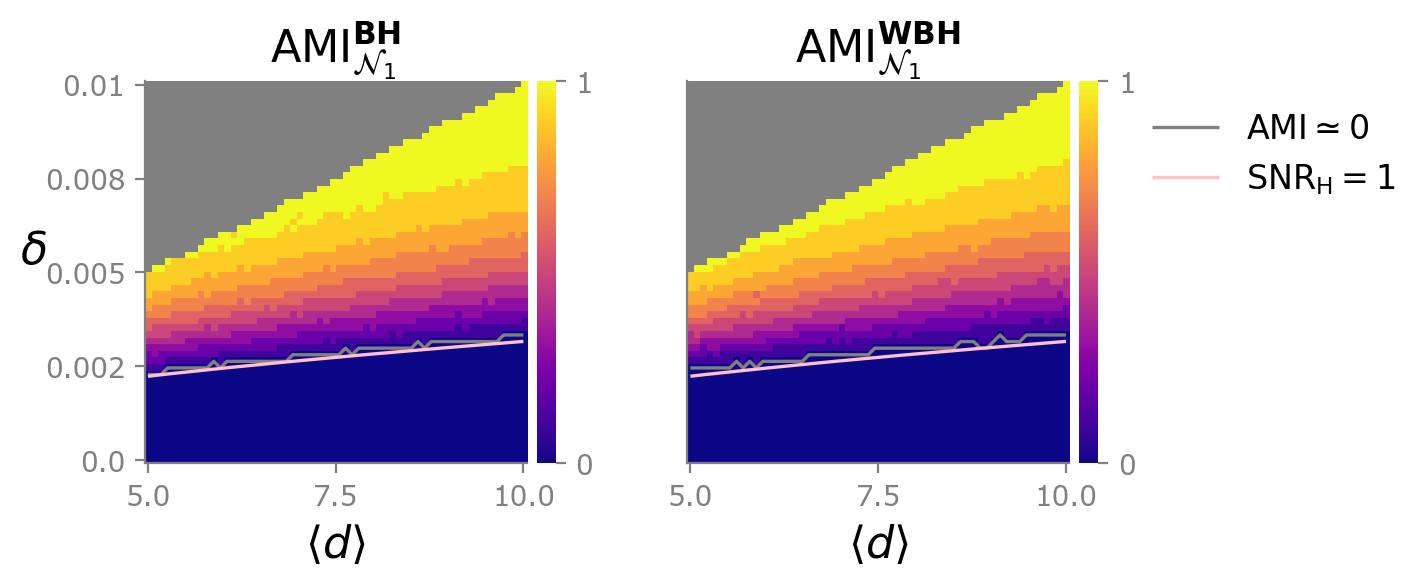

In [106]:
fig = plt.figure(figsize=(6.2, 3))
widths = [3, 3]
heights = [3]
spec5 = fig.add_gridspec(ncols=2, nrows=1, width_ratios=widths, height_ratios=heights)
handels = []

row = 0
col = 0
ax = fig.add_subplot(spec5[row, col])
cmap = mpl.colormaps["plasma"]
cmap = cmap.with_extremes(bad="gray", under="gray", over="gray")
plot_sub1ami = color_imshow_2d(plot_ds, plot_deltas, sub1_amis, z_center=0.5, title=r"$\mathrm{AMI}_{\mathcal{N}_1}^{\bf BH}$", xlabel=r"$\left<d\right>$", ylabel=r"$\delta$", 
                min_z=0, max_z=1, cmap=cmap, ax=ax, fig=fig, return_gridz=False, set_xticks=True, set_yticks=True, vmin=0, vmax=1, ytickprecision=3,
                    cticks=[0, 1])
filtered_plot_sub1ami = np.where(np.abs(plot_sub1ami) < 0.5, plot_sub1ami, np.nan)
handels += contour_data(filtered_plot_sub1ami, ax, levels=[1e-4], fmt={1e-4: r'$\rm AMI$\simeq$0$'}, color='gray', inline=False)
plot_sub1snr = color_imshow_2d(plot_ds, plot_deltas, sub1_snrs, z_center=1, return_gridz=True)
handels += contour_data(plot_sub1snr, ax, levels=[1], fmt={1: r'$\rm SNR_{H}=1$'}, color='pink', inline=False)


row = 0
col = 1
ax = fig.add_subplot(spec5[row, col])
cmap = mpl.colormaps["plasma"]
cmap = cmap.with_extremes(bad="gray", under="gray", over="gray")
plot_sub1ami = color_imshow_2d(om_plot_ds, om_plot_deltas, om_amis, z_center=0.5, title=r"$\mathrm{AMI}_{\mathcal{N}_1}^{\bf WBH}$", xlabel=r"$\left<d\right>$", ylabel=r"", 
                min_z=0, max_z=1, cmap=cmap, ax=ax, fig=fig, return_gridz=False, set_xticks=True, set_yticks=False, vmin=0, vmax=1, ytickprecision=3,
                    cticks=[0, 1])
filtered_plot_om_ami = np.where(np.abs(plot_sub1ami) < 0.5, plot_sub1ami, np.nan)
contour_data(filtered_plot_om_ami, ax, levels=[1e-4], fmt={1e-4: r'$\rm AMI$\simeq$0$'}, color='gray', inline=False)
plot_sub1snr = color_imshow_2d(plot_ds, plot_deltas, sub1_snrs, z_center=1, return_gridz=True)
contour_data(plot_sub1snr, ax, levels=[1], fmt={1: r'$\rm SNR_{H}=1$'}, color='pink', inline=False)


lgd = fig.legend(handels, [r'$\rm AMI\simeq 0$', r'$\rm SNR_{H}=1$'], loc=2, bbox_to_anchor=(0.94, 0.85),  fontsize=12, markerscale=2, frameon=False)
plt.tight_layout()

save_path = f"./_Figure/Thesis/" + f"Figure5.4_ExpSNRH_onemodeproj_largen.pdf"
plt.savefig(save_path, dpi=600, bbox_extra_artists=(lgd,), bbox_inches='tight')

In [86]:
n1 = 2000
q1 = 2
delta = 0.004
d = 7
bsbm, full_partition, full_numgroups, full_ami, full_snr, sub1_numgroups, sub1_ami, sub1_snr = symBSBM(n1=n1, q1=q1, delta=delta, d=d, verbose=True)

a=0.0055, b=0.0015
[0.007 0.004]
SNR of full bipartite network is 7.000000000000001, the first partite is 2.2857142857142843
number of groups = 4, Kpos=2, Kneg=2
Detect 4 communities, the AMI of full is 0.7430645906791497, of sub1 is 0.49187490096833


In [ ]:
AA = bsbm.A.dot(bsbm.A)
AA = AA - diags(np.diag(AA.toarray()), 0)  # remove diagonal
BBT = AA[:n1, :n1]
BBT_BHpartition, BBT_BHnumgroups = CommunityDetect(BBT).BetheHessian(num_groups=q1, weighted=True, only_assortative=False)
BBT_BH_ami = adjusted_mutual_info_score(bsbm.groupId[:n1], BBT_BHpartition)
print(f"WBH on BBT, ami={BBT_BH_ami}")

# Minority 2,2 consistent pout different method (only show # community)

In [1]:
from _SBMMatrix import *
from _FigureJiazeHelper import *
import matplotlib.pyplot as plt
from matplotlib.patches import Ellipse, Circle
from scipy.sparse.linalg import eigs, eigsh
from scipy.linalg import eig
from _CommunityDetect import *
from EXPERIMENT_MINORITY import *
from spectralOperator import BetheHessian
from hypergraphx.viz import draw_communities
from matplotlib.colors import LinearSegmentedColormap
from EXPERIMENT_MinoritySameDegree import get_ps, read_exp
import warnings
warnings.filterwarnings('ignore', category=FutureWarning)

%load_ext autoreload
%autoreload 2

In [2]:
# Matplotlib settings

# plt.style.use('seaborn-whitegrid')
plt.rc('figure', figsize=(8, 5))
plt.rc('font', size=16)
plt.rc('font', family='sans-serif')
plt.rcParams['font.sans-serif'] = 'verdana'
plt.rcParams['lines.linewidth'] = 4
plt.rcParams['axes.spines.right'] = False
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.edgecolor'] = basic_line_color
plt.rcParams['xtick.color'] = basic_line_color
plt.rcParams['ytick.color'] = basic_line_color
plt.rcParams['axes.labelsize'] = 'large'
plt.rcParams['lines.markersize'] = 12

%config InlineBackend.figure_format = 'retina'

In [5]:
def explore_lambdas(n=6000, d=5, Z_s=2, Z_b=3, rho_len=504, delta_len=502, consist_d=True, assortative=False, minority_s=True, num_lambda=4):
    q = Z_s + Z_b
    if minority_s:
        max_rho = Z_s/q
    rhos = np.setdiff1d(np.around(np.linspace(0, max_rho, rho_len), 6), np.array([0, 0.5, max_rho, 1]))
    min_delta, max_delta = None, None
    for r in rhos:
        for delta in np.setdiff1d(np.around(np.linspace(-1, 1, 10000), 6), np.array([])):
            if consist_d:
                _, pin, pout1, pout2 = get_ps(n, d, Z_s, Z_b, r, delta, Type=2)
                if 0 <= pin <= 1 and 0 <= pout1 <= 1 and 0 <= pout2 <= 1:
                    min_delta = delta if min_delta is None or delta < min_delta else min_delta
                    max_delta = delta if max_delta is None or delta > max_delta else max_delta
            else:
                pout = d / n - ((1-r)**2 / Z_b + r**2 / Z_s) * delta
                pin = pout + delta
                if 0 <= pin <= 1 and 0 <= pout <= 1:
                    min_delta = delta if min_delta is None or delta < min_delta else min_delta
                    max_delta = delta if max_delta is None or delta > max_delta else max_delta
    if assortative:
        min_delta = 0  # only consider assortative case
    
        
    deltas = np.setdiff1d(np.around(np.linspace(min_delta, max_delta, delta_len), 5), np.array([0]))
    print(f"max_rho={max_rho}, min_delta={min_delta}, max_delta={max_delta}")
    
    lambdas = np.zeros((np.size(deltas) * np.size(rhos), num_lambda))
    max_snr = 0
    expi = 0
    exp_samples = 0
    exp_samples_oversnr = 0
    for rho in rhos:
        for delta in deltas:
            if consist_d:
                ps, pin, pout1, pout2 = get_ps(n, d, Z_s, Z_b, rho, delta, Type)
                if pin < 0 or pin > 1 or pout1 < 0 or pout1 > 1 or pout2 < 0 or pout2 > 1:
                    # for delta let pin pout not in [0, 1], return (-1,0)
                    # print(f"rho={rho}, delta={delta}, pin={pin}, pout1={pout1}, pout2={pout2}, wrong")
                    lambdas[expi, :] = [1, np.inf, np.inf, np.inf]
                else:
                    P = np.diag([rho / Z_s] * Z_s + [(1 - rho) / Z_b] * Z_b)
                    Q = n * ps
                    lambdas[expi, :] = MetaSBM.get_lambdas_homoDegree(n, d, Z_s, Z_b, rho, delta, Type=Type)
                    snr = lambdas[expi, 1]**2/lambdas[expi, 0]
                    if snr is not np.inf and snr>max_snr:
                        max_snr = snr
                    exp_samples += 1
                    if snr > 1:
                        exp_samples_oversnr += 1
                    # print(f'rho={rho}, delta={delta}, lambdas_PQ={lambdas}')
            else:
                pout = d / n - ((1-rho)**2 / Z_b + rho**2 / Z_s) * delta
                pin = pout + delta
                ps = (pin - pout) * np.identity(q) + pout * np.ones((q, q))
                if pin < 0 or pin > 1 or pout < 0 or pout > 1:
                    lambdas[expi, :] = [1] + [np.inf] * (num_lambda-1)  # [1, np.inf, np.inf, np.inf]
                else:
                    P = np.diag([rho / Z_s] * Z_s + [(1 - rho) / Z_b] * Z_b)
                    Q = n * ps
                    lambdas[expi, :] = MetaSBM.get_lambdas(n, rho, Z_s, Z_b, pin, pout)
                    snr = lambdas[expi, 1]**2/lambdas[expi, 0]
                    if snr is not np.inf and snr>max_snr:
                        max_snr = snr
                    exp_samples += 1
                    if snr > 1:
                        exp_samples_oversnr += 1
            expi += 1
    print(f'Experiment samples {exp_samples}, with snr>1 samples {exp_samples_oversnr}')
    return rhos, deltas, lambdas, max_snr

In [3]:
# For big n
n = 6000
d = 5
Z_s = 2
Z_b = 2
q = Z_s + Z_b
Withlambda = True
givenNumGroup = False
DC = False
BP = False
skip_snrlower1 = True
fileID = 'amiExp25.4.5' + f'_n={n}_qs={Z_s}_qb={Z_b}_d={round(d)}_{"lambda" if Withlambda else ""}_'\
                          f'{"givenNumGroup" if givenNumGroup else ""}_' \
                          f'{"DC" if DC else ""}_{"skipSNR_1" if skip_snrlower1 else ""}'
load_path = "./result/detectabilityWithMeta/" + fileID + ".txt"
addition_id = "30more"
fileID = 'amiExp25.4.5' + f'_n={n}_qs={Z_s}_qb={Z_b}_d={round(d)}_{"lambda" if Withlambda else ""}_'\
                              f'{"givenNumGroup" if givenNumGroup else ""}_' \
                              f'{"DC" if DC else ""}_{"skipSNR_1" if skip_snrlower1 else ""}_{addition_id}'
add_paths = ["./result/detectabilityWithMeta/" + fileID + ".txt"]
exclude_rho = None
plot_rhos, plot_zs, sub_ami, BH_BH_sub_num_group, lambdas = read_exp(load_path=load_path, Withlambda=Withlambda, exclude_rho=exclude_rho, add_paths=add_paths)

Withlambda = True
givenNumGroup = False
DC = False
BP = True
learnqby = None
givenTrueEpsilon = False
writeCM = False
skip_snrlower1 = True
additionId = "BP_learnq_NegEig"
fileID = 'amiExp25.4.8' + f'_n={n}_q={q}_d={round(d)}_{"lambda" if Withlambda else ""}_' \
                           f'{"givenNumGroup" if givenNumGroup else ""}_' \
                           f'{"DC" if DC else ""}_{"BP" if BP else ""}_' \
                           f'{"givenTrueEpsilon" if givenTrueEpsilon else ""}_{"writeCM" if writeCM else ""}_' \
                           f'{additionId}'
load_path = "./result/detectabilityWithMeta/" + fileID + ".txt"
add_paths = []
exclude_rho = None
plot_rhos, plot_zs, sub_ami, BP_BH_sub_num_group, lambdas = read_exp(load_path=load_path, Withlambda=Withlambda, exclude_rho=exclude_rho, add_paths=add_paths)

Withlambda = True
givenNumGroup = False
DC = False
BP = False
learnqby = "MDL"
givenTrueEpsilon = False
writeCM = False
skip_snrlower1 = True
additionId = "BH_learnq_MDL"
fileID = 'amiExp25.4.8' + f'_n={n}_qs={Z_s}_qb={Z_b}_d={round(d)}_{"lambda" if Withlambda else ""}_' \
                           f'{"givenNumGroup" if givenNumGroup else ""}_' \
                           f'{"DC" if DC else ""}_{"BP" if BP else ""}_' \
                           f'{"givenTrueEpsilon" if givenTrueEpsilon else ""}_{"writeCM" if writeCM else ""}_' \
                           f'{additionId}'
load_path = "./result/detectabilityWithMeta/" + fileID + ".txt"
add_paths = []
exclude_rho = None
plot_rhos, plot_zs, sub_ami, BH_MDL_sub_num_group, lambdas = read_exp(load_path=load_path, Withlambda=Withlambda, exclude_rho=exclude_rho, add_paths=add_paths)

Withlambda = True
givenNumGroup = False
DC = False
BP = True
learnqby = "MDL"
givenTrueEpsilon = False
writeCM = False
skip_snrlower1 = True
additionId = "BP_learnq_MDL"
fileID = 'amiExp25.4.8' + f'_n={n}_qs={Z_s}_qb={Z_b}_d={round(d)}_{"lambda" if Withlambda else ""}_' \
                           f'{"givenNumGroup" if givenNumGroup else ""}_' \
                           f'{"DC" if DC else ""}_{"BP" if BP else ""}_' \
                           f'{"givenTrueEpsilon" if givenTrueEpsilon else ""}_{"writeCM" if writeCM else ""}_' \
                           f'{additionId}'
load_path = "./result/detectabilityWithMeta/" + fileID + ".txt"
add_paths = []
exclude_rho = None
plot_rhos, plot_zs, sub_ami, BP_MDL_sub_num_group, lambdas = read_exp(load_path=load_path, Withlambda=Withlambda, exclude_rho=exclude_rho, add_paths=add_paths)

Withlambda = True
givenNumGroup = False
DC = False
BP = True
learnqby = "FE"
givenTrueEpsilon = False
writeCM = False
skip_snrlower1 = True
additionId = "BP_learnq_FE"
fileID = 'amiExp25.4.8' + f'_n={n}_qs={Z_s}_qb={Z_b}_d={round(d)}_{"lambda" if Withlambda else ""}_' \
                           f'{"givenNumGroup" if givenNumGroup else ""}_' \
                           f'{"DC" if DC else ""}_{"BP" if BP else ""}_' \
                           f'{"givenTrueEpsilon" if givenTrueEpsilon else ""}_{"writeCM" if writeCM else ""}_' \
                           f'{additionId}'
load_path = "./result/detectabilityWithMeta/" + fileID + ".txt"
add_paths = []
exclude_rho = None
plot_rhos, plot_zs, sub_ami, BP_FE_sub_num_group, lambdas = read_exp(load_path=load_path, Withlambda=Withlambda, exclude_rho=exclude_rho, add_paths=add_paths)

Additional result adding...
Additional result adding...
Additional result adding...
Additional result adding...
Additional result adding...


max_rho=0.5, min_delta=0, max_delta=0.0033
Experiment samples 2081, with snr>1 samples 1274


D:\Work\PhD\_code\_nodeclassification\_FigureJiazeHelper.py:143: RuntimeWarning: invalid value encountered in scalar divide
  else:


setting xticks
setting xticks
setting xticks
minz=1, maxz=5, cticks=[0.         0.26666667 0.53333333 0.8       ], clabel=['1', '2', '3', '4']


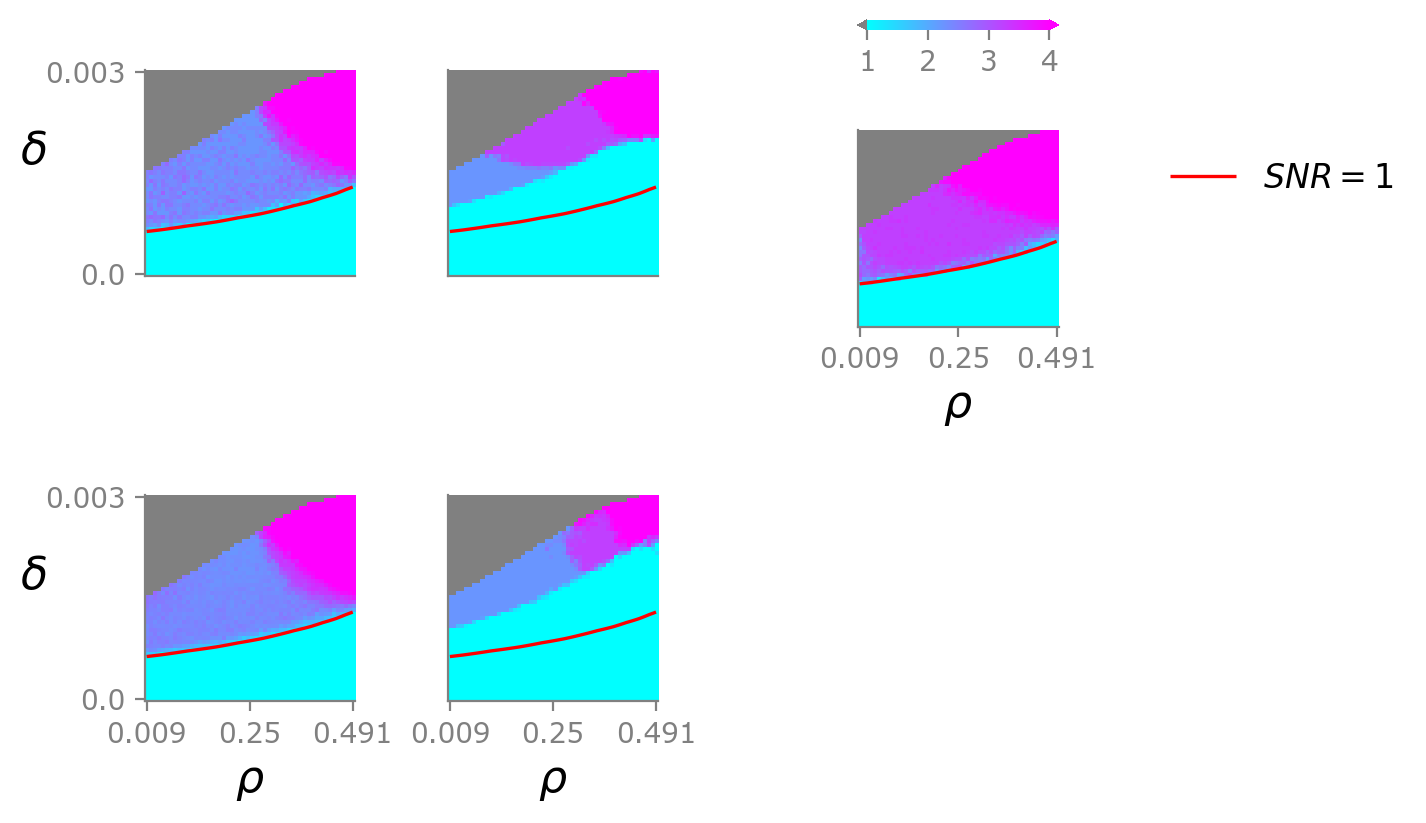

In [21]:
rhos, deltas, _, _ = explore_lambdas(n=6000, d=5, Z_s=2, Z_b=2, rho_len=54, delta_len=52, assortative=True, consist_d=False, num_lambda=4)
i = 0
for _rho in rhos:
    for _delta in deltas:
        pout = d / n - ((1-_rho)**2 / Z_b + _rho**2 / Z_s) * _delta
        pin = pout + _delta
        if pin < 0 or pin > 1 or pout < 0 or pout > 1:
            sub_ami[i] = -1
            BP_BH_sub_num_group[i] = -1
            BH_BH_sub_num_group[i] = -1
            lambdas[i] = [1, np.inf, np.inf, np.inf]
        i += 1
# figsize (width, height) with inch, 1 inch = 72 pt
fig = plt.figure(figsize=(6, 4), layout='constrained')
# fig = plt.figure(figsize=(16, 16))
widths = [3, 3, 7]
heights = [5, 5]
spec5 = fig.add_gridspec(ncols=3, nrows=2, width_ratios=widths, height_ratios=heights)
row = 0
col = 0
ax = fig.add_subplot(spec5[row, col])

# fig, axs = plt.subplots(3, 2, sharex=True, layout='constrained', figsize=(4, 6))
# ax = axs[0][0]
cmap = mpl.colormaps["cool"]
cmap.set_extremes(under='gray')
zcenter = 2.5
plot_subnumgroup = color_imshow_2d(plot_rhos, plot_zs, BP_BH_sub_num_group, z_center=zcenter, title="", xlabel=r'', ylabel=r'$\delta$',
                                   min_z=1, max_z=5, cmap=cmap,
                                   ax=ax, fig=fig, set_yticks=True,set_xticks=False, vmin=1, vmax=Z_s+Z_b, ytickprecision=3, yticks_num=2,
                                   show_colorbar=False, show_ext_color=True, top_cbar=True)
# ax.set_xlabel(r'$\rho$', fontsize=20)
plot_snrm = color_imshow_2d(plot_rhos, plot_zs, lambdas[:, 1]**2/lambdas[:, 0], z_center=1, return_gridz=True)
handels = []
handels += contour_data(plot_snrm, ax, levels=[1], fmt={1: r'$SNR=1$'}, color='red', inline=False)

row = 1
col = 0
ax = fig.add_subplot(spec5[row, col])
# ax = axs[0][1]
cmap = mpl.colormaps["cool"]
cmap.set_extremes(under='gray')
zcenter = 2.5
plot_subnumgroup = color_imshow_2d(plot_rhos, plot_zs, BH_BH_sub_num_group, z_center=zcenter, title="", xlabel=r'$\rho$', ylabel=r'$\delta$',
                                   min_z=1, max_z=5, cmap=cmap,
                                   ax=ax, fig=fig, set_yticks=True, vmin=1, vmax=Z_s+Z_b, ytickprecision=3, yticks_num=2,
                                   show_colorbar=False, show_ext_color=True, top_cbar=True)
# ax.set_xlabel(r'$\rho$', fontsize=20)
plot_snrm = color_imshow_2d(plot_rhos, plot_zs, lambdas[:, 1]**2/lambdas[:, 0], z_center=1, return_gridz=True)
contour_data(plot_snrm, ax, levels=[1], fmt={1: r'$SNR=1$'}, color='red', inline=False)

row = 0
col = 1
ax = fig.add_subplot(spec5[row, col])
# ax = axs[1][0]
cmap = mpl.colormaps["cool"]
cmap.set_extremes(under='gray')
zcenter = 2.5
plot_subnumgroup = color_imshow_2d(plot_rhos, plot_zs, BP_MDL_sub_num_group, z_center=zcenter, title="", xlabel=r'', ylabel=r'',
                                   min_z=1, max_z=5, cmap=cmap,
                                   ax=ax, fig=fig, set_yticks=False, set_xticks=False, vmin=1, vmax=Z_s+Z_b, ytickprecision=3, show_colorbar=False, show_ext_color=True, top_cbar=False)
# ax.set_xlabel(r'$\rho$', fontsize=20)
plot_snrm = color_imshow_2d(plot_rhos, plot_zs, lambdas[:, 1]**2/lambdas[:, 0], z_center=1, return_gridz=True)
contour_data(plot_snrm, ax, levels=[1], fmt={1: r'$SNR=1$'}, color='red', inline=False)

row = 1
col = 1
ax = fig.add_subplot(spec5[row, col])
# ax = axs[1][1]
cmap = mpl.colormaps["cool"]
cmap.set_extremes(under='gray')
zcenter = 2.5
plot_subnumgroup = color_imshow_2d(plot_rhos, plot_zs, BH_MDL_sub_num_group, z_center=zcenter, title="", xlabel=r'$\rho$', ylabel=r'',
                                   min_z=1, max_z=5, cmap=cmap,
                                   ax=ax, fig=fig, set_yticks=False, vmin=1, vmax=Z_s+Z_b, ytickprecision=3, show_colorbar=False, show_ext_color=True, top_cbar=False)
# ax.set_xlabel(r'$\rho$', fontsize=20)
plot_snrm = color_imshow_2d(plot_rhos, plot_zs, lambdas[:, 1]**2/lambdas[:, 0], z_center=1, return_gridz=True)
contour_data(plot_snrm, ax, levels=[1], fmt={1: r'$SNR=1$'}, color='red', inline=False)

row = 0
col = 2
ax = fig.add_subplot(spec5[row, col])
# ax = axs[2][0]
cmap = mpl.colormaps["cool"]
cmap.set_extremes(under='gray')
zcenter = 2.5
plot_subnumgroup = color_imshow_2d(plot_rhos, plot_zs, BP_FE_sub_num_group, z_center=zcenter, title="", xlabel=r'$\rho$', ylabel=r'',
                                   min_z=1, max_z=5, cmap=cmap,
                                   ax=ax, fig=fig, set_yticks=False, vmin=1, vmax=Z_s+Z_b, ytickprecision=3, show_colorbar=True, show_ext_color=True, top_cbar=True)
# ax.set_xlabel(r'$\rho$', fontsize=20)
plot_snrm = color_imshow_2d(plot_rhos, plot_zs, lambdas[:, 1]**2/lambdas[:, 0], z_center=1, return_gridz=True)
contour_data(plot_snrm, ax, levels=[1], fmt={1: r'$SNR=1$'}, color='red', inline=False)

lgd = fig.legend(handels, [r'$SNR=1$', r'$\frac{\lambda_3^2}{\lambda_1}=1$', r'$\frac{\lambda_4^2}{\lambda_1}=1$'], 
           loc=2, bbox_to_anchor=(0.94, 0.85),  fontsize=12, markerscale=2, frameon=False)
save_path = "./_Figure/Thesis/" + "FigureChap3.2_Minority_numberofcommunities_samepout" + f'd{d}Z_s{Z_s}Z_b{Z_b}' + ".pdf"
plt.savefig(save_path, dpi=600, bbox_extra_artists=(lgd,), bbox_inches='tight')

# Minority BP free energy plot with q

In [22]:
import matplotlib.pyplot as plt
import matplotlib as mpl
import contourpy
from matplotlib.colors import LinearSegmentedColormap
import matplotlib.colors as colors
from matplotlib.ticker import FormatStrFormatter
import numpy as np
from _FigureJiazeHelper import *
from _DetectabilityWithMeta import *
from _CommunityDetect import *
from EXPERIMENT_MINORITY import *
from scipy.optimize import linear_sum_assignment

%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [23]:
# Matplotlib settings

# plt.style.use('seaborn-whitegrid')
plt.rc('figure', figsize=(8, 5))
plt.rc('font', size=10)
plt.rc('font', family='sans-serif')
plt.rcParams['font.sans-serif'] = 'verdana'
plt.rcParams['lines.linewidth'] = 4
plt.rcParams['axes.spines.right'] = False
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.edgecolor'] = basic_line_color
plt.rcParams['xtick.color'] = basic_line_color
plt.rcParams['ytick.color'] = basic_line_color
plt.rcParams['axes.labelsize'] = 10  # 'large'
plt.rcParams['lines.markersize'] = 12
plt.rcParams['axes.linewidth'] = 0.5

# %matplotlib notebook
%config InlineBackend.figure_format = 'retina'

q=[1. 2. 3. 4. 5. 6. 7.], min_f=[-1.47935, -1.55526, -1.62168, -1.63588, -1.6365, -1.63734, -1.63656],
diff_min_f=[-0.07591, -0.06642, -0.0142, -0.00062, -0.00084, 0.00078]
Confusion Matrix of Final Partition:
 332.  146.  107.   93.
 352.  129.  128.  118.
 110. 1365.   42.   24.
 141.   41. 1315.   27.
 174.   38.   38. 1243.


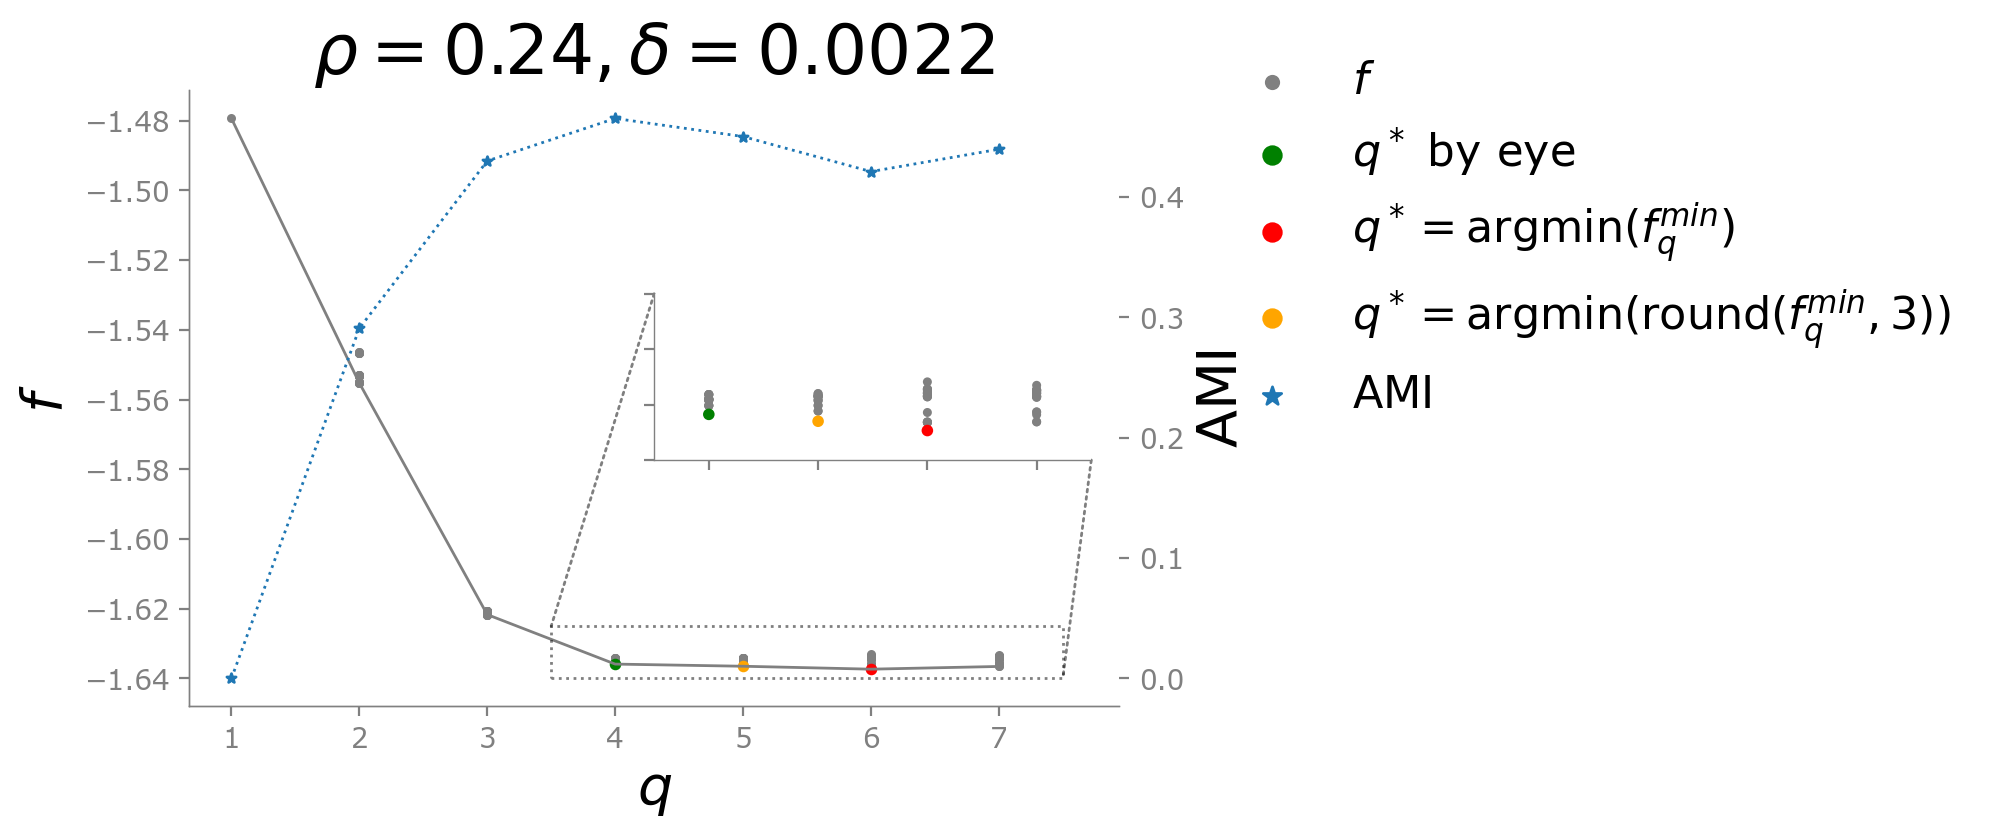

In [27]:
rho = 0.24
delta = 0.0022
fileName = "6.17_2ndType_multiInitBH_n=6000d=5Zs=2Zb=3rho=0.24delta=0.0022t=0_BPlearnq_FreeEnergy_998245_inite0.2.txt"
filepath = "./result/test_record_f/" + fileName
# observe_f("./result/test_record_f/" + fileName, fileName, rho=0.24, delta=0.0022, fig=fig, ax=ax)
results = []
with open(filepath, 'r') as fr:
    for line in fr.readlines():
        line = line.strip().split(" ")
        if line[0] == 'Finial':
            break
        result_line = []
        for datastr in line:
            # print(datastr)
            result_line.append(float(datastr.split("=")[1]))
        results.append(result_line)
results = np.array(results)

fig = plt.figure(figsize=(6, 4))
widths = [4]
heights = [3]
spec5 = fig.add_gridspec(ncols=1, nrows=1, width_ratios=widths, height_ratios=heights)
row = 0
col = 0
ax = fig.add_subplot(spec5[row, col])
ax1 = ax.scatter(results[:, 0], results[:, 2], s=5, color="gray", label=r"$f$")
x = np.sort(np.unique(results[:, 0]))
y = []
for xi in x:
    y.append(np.min(results[np.argwhere(results[:, 0]==xi)[:, 0], :][:, 3]))
print(f'q={x}, min_f={y},\ndiff_min_f={[np.around(y[i+1] - y[i], 5) for i in range(len(y)-1)]}')
ax.plot(x, y, '-', lw=1, color='gray')
ax.set_xlabel(r"$q$", fontsize=20)
ax.set_ylabel(r"$f$", fontsize=20)
# fileName = filepath.split('/')[4]
ax.set_title(rf'$\rho={rho}, \delta={delta}$', fontsize=25)

cm_file = f'./result/confusionMatrix/{fileName.split("_BPlearnq_FreeEnergy_")[0]}.txt'
print('Confusion Matrix of Final Partition:')
with open(cm_file, 'r') as fr:
    for line in fr.readlines():
        line = line.strip().replace('[', '').replace(']', '')
        print(line)


ax2 = ax.scatter(4, -1.63588, s=10, color='green', label=r'$q^*$ by eye')
ax3 = ax.scatter(6, -1.63734, s=10, color='red', label=r'$q^*=\mathrm{argmin}(f_q^{min})$ ')
ax4 = ax.scatter(5, -1.6365, s=10, color='orange', label=r'$q^*=\mathrm{argmin}(\mathrm{round}(f_q^{min}, 3))$ ')
# lgd = plt.legend(loc=2, bbox_to_anchor=(1.15, 1.0), fontsize=10, markerscale=2)

x1, x2, y1, y2 = 3.5, 7.5, -1.64, -1.625  # subregion of the original image
axins = ax.inset_axes(
    [0.5, 0.4, 0.47, 0.27],
    xlim=(x1, x2), ylim=(y1, y2), xticklabels=[], yticklabels=[])
sub_points_x = []
sub_points_y = []
sub_points_c = []
sub_points_s = []
for r in range(np.shape(results)[0]):
    if x1 < results[r, 0] < x2:
        sub_points_x.append(results[r, 0])
        sub_points_y.append(results[r, 2])
        sub_points_c.append('gray')
        sub_points_s.append(5)

sub_points_x.append(4)
sub_points_y.append(-1.63588)
sub_points_c.append('green')
sub_points_s.append(10)

sub_points_x.append(5)
sub_points_y.append(-1.6365)
sub_points_c.append('orange')
sub_points_s.append(10)

sub_points_x.append(6)
sub_points_y.append(-1.63734)
sub_points_c.append('red')
sub_points_s.append(10)
axins.scatter(sub_points_x, sub_points_y, s=sub_points_s, c=sub_points_c)
axins.set_xticks([4, 5, 6, 7])
# axins.axhline(0, color='grey', lw=1, ls=':')
_, connectionpath = ax.indicate_inset_zoom(axins, edgecolor="black", ls=':')
for p in connectionpath:
    p.set(linestyle=':')
ax.set_xticks(x)

ax_twin = ax.twinx()
xs = [1, 2, 3, 4, 5, 6, 7]
amis = [0]
for q in [2, 3, 4, 5, 6, 7]:
    cm_file = f'./result/confusionMatrix/6.17_2ndType_multiInitBH_n=6000d=5Zs=2Zb=3rho=0.24delta=0.0022t=0_q={q}.txt'
    with open(cm_file, 'r') as fr:
        for line in fr.readlines():
            if '[' in line or ']' in line:
                continue
            else:
                amis.append(float(line.strip()))
ax5 = ax_twin.scatter(xs, amis, s=12, marker='*', label=r'$\rm AMI$')
ax_twin.plot(xs, amis, ':', linewidth=1)
ax_twin.set_ylabel(r'$\rm AMI$', fontsize=20)
axs = [ax1,ax2,ax3,ax4,ax5]
lables = [a.get_label() for a in axs]
lgd = ax.legend(axs, lables, loc=2, bbox_to_anchor=(1.15, 1.0),  fontsize=16, markerscale=2, frameon=False, borderaxespad=-1.1)
# lgd = fig.legend(handels, [r"$f$", r'$q^*$ by eye', r'$q^*=\mathrm{argmin}(f_q^{min})$ ', r'$q^*=\mathrm{argmin}(\mathrm{round}(f_q^{min}, 3))$ ',
#                           r'$AMI$'], 
#            loc=2, bbox_to_anchor=(1.15, 1.0),  fontsize=12, markerscale=2, frameon=True)
save_path = "./_Figure/Thesis/" + f"FigureAppendix_MinorityBPf_rho{rho}delta{delta}_v1.pdf"
# plt.tight_layout()
plt.savefig(save_path, dpi=600, bbox_extra_artists=(lgd,), bbox_inches='tight')